In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL

In [3]:
!pip install pymannkendall -q

In [4]:
import pymannkendall as mk

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
file_path = "/content/drive/MyDrive/sih/groundwater_clean_final.csv"

df = pd.read_csv(file_path)

In [7]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nStations:", df["Station"].nunique())

print("\nMissing groundwater values:")
print(df["Groundwater_Level_Final"].isna().sum())

print("\nDuplicate Station-Timestamp records:")
print(df.duplicated(["Station", "Timestamp"]).sum())

Dataset shape: (36117, 4)

Columns:
['Station', 'Timestamp', 'Groundwater_Level_Final', 'Quality_Flag']

Stations: 15

Missing groundwater values:
5127

Duplicate Station-Timestamp records:
0


In [8]:
trend_df = df.dropna(subset=["Groundwater_Level_Final"]).copy()

trend_df = trend_df[
    ["Station", "Timestamp", "Groundwater_Level_Final"]
].copy()

trend_df = trend_df.sort_values(
    ["Station", "Timestamp"]
).reset_index(drop=True)

print("Records available for trend analysis:", len(trend_df))

Records available for trend analysis: 30990


In [9]:
trend_df["Month"] = trend_df["Timestamp"].dt.to_period("M")

monthly_df = (
    trend_df
    .groupby(["Station", "Month"])["Groundwater_Level_Final"]
    .mean()
    .reset_index()
)

monthly_df["Timestamp"] = monthly_df["Month"].dt.to_timestamp()

monthly_df = monthly_df.sort_values(
    ["Station", "Timestamp"]
).reset_index(drop=True)

print("Monthly dataset shape:", monthly_df.shape)

monthly_df.head()

Monthly dataset shape: (331, 4)


,Station,Month,Groundwater_Level_Final,Timestamp
0,Bajengdoba_1,2023-05,-5.277714,2023-05-01
1,Bajengdoba_1,2023-06,-4.778125,2023-06-01
2,Bajengdoba_1,2023-07,-4.756750,2023-07-01
3,Bajengdoba_1,2023-08,-4.816935,2023-08-01
4,Bajengdoba_1,2023-09,-4.741071,2023-09-01


In [10]:
monthly_counts = (
    monthly_df
    .groupby("Station")
    .size()
    .sort_values()
)

print(monthly_counts)

Station
Chasingre (NEHU)         5
Jengjal                 10
Tdohumshiaw             12
Nongladew_2             14
RPBF Kyrdemkulai_1      18
Rongram_1               21
Dadenggre_1             23
Mendipathar_1           23
Powergrid Khliehriat    25
Bajengdoba_1            25
Mendal_1                31
NIT Cherrapunji         31
Nongladew_1             31
Purduwa_1               31
W.R.D., Shillong        31
dtype: int64


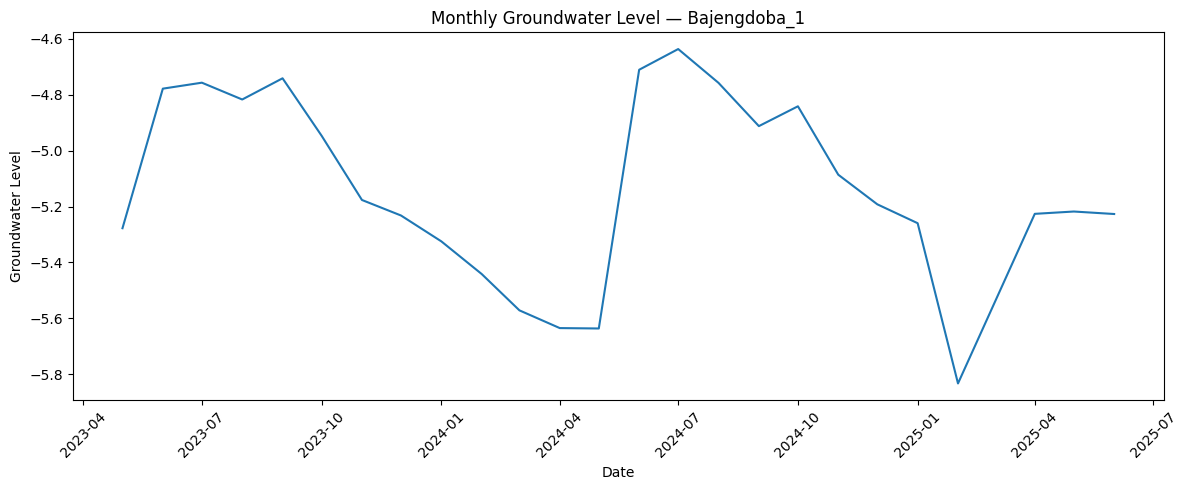

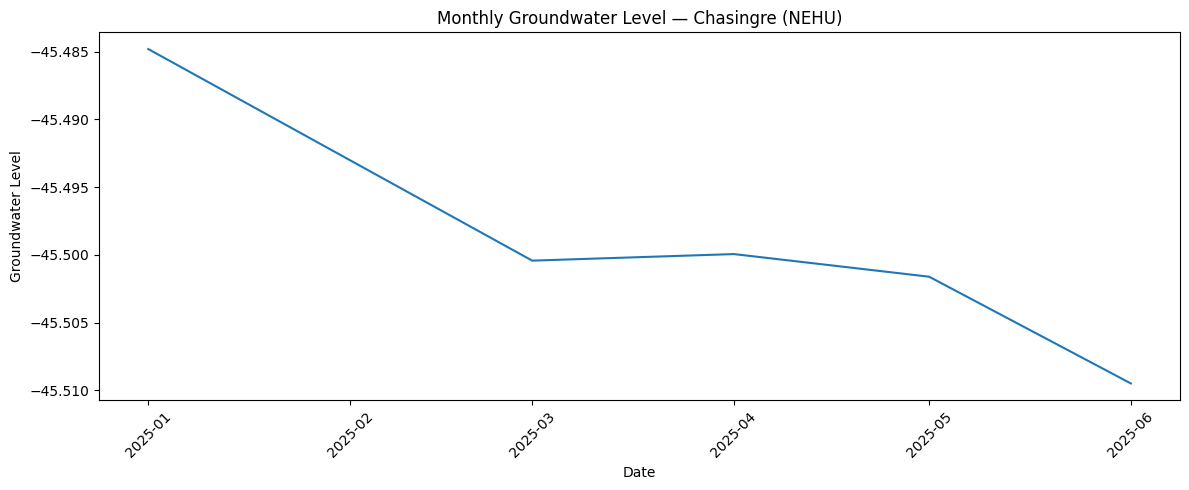

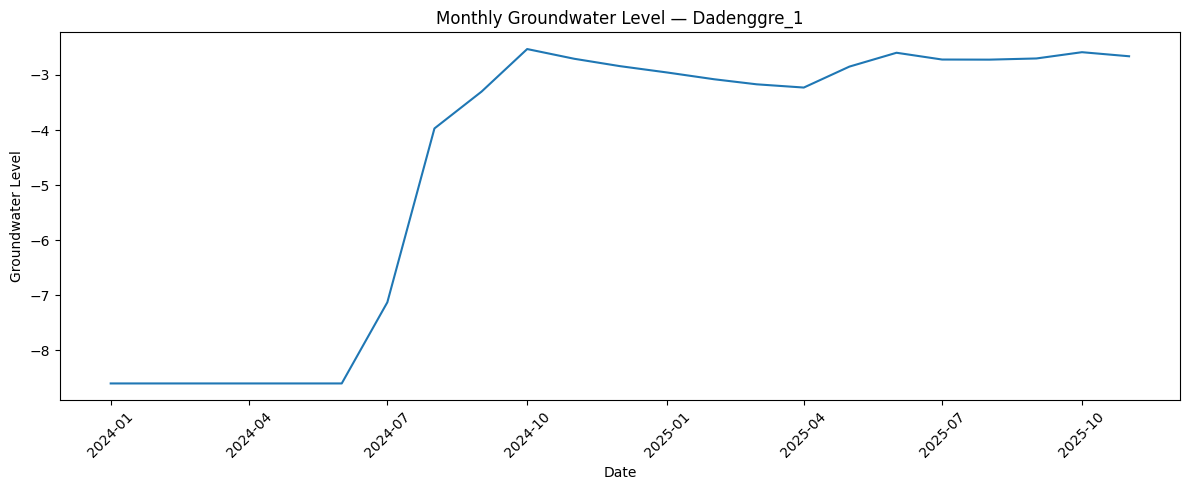

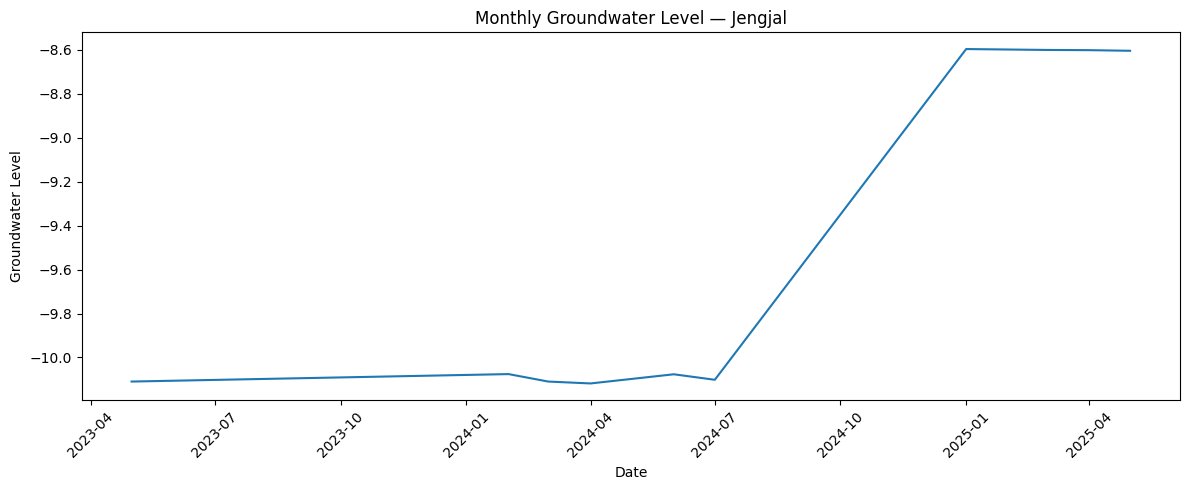

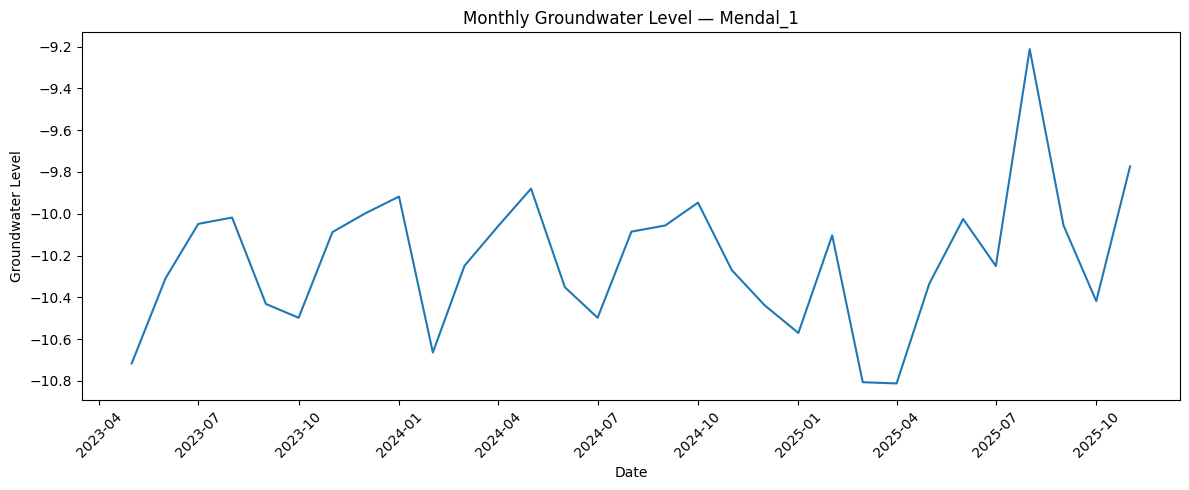

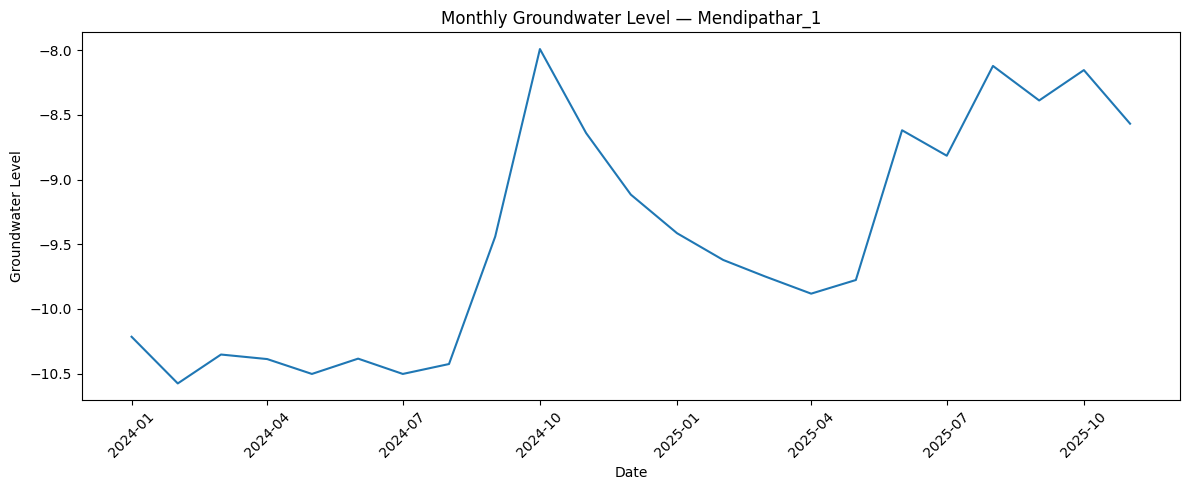

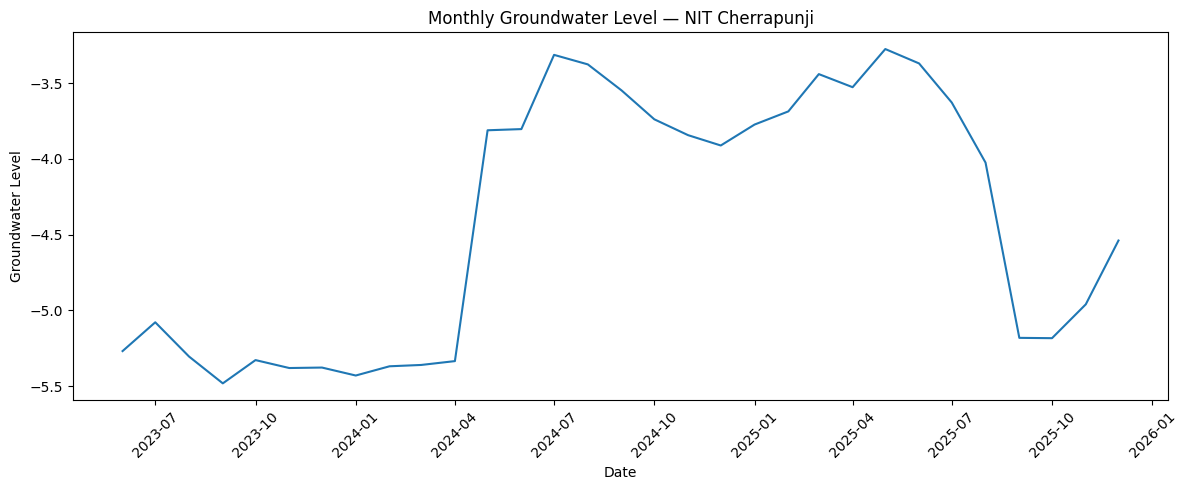

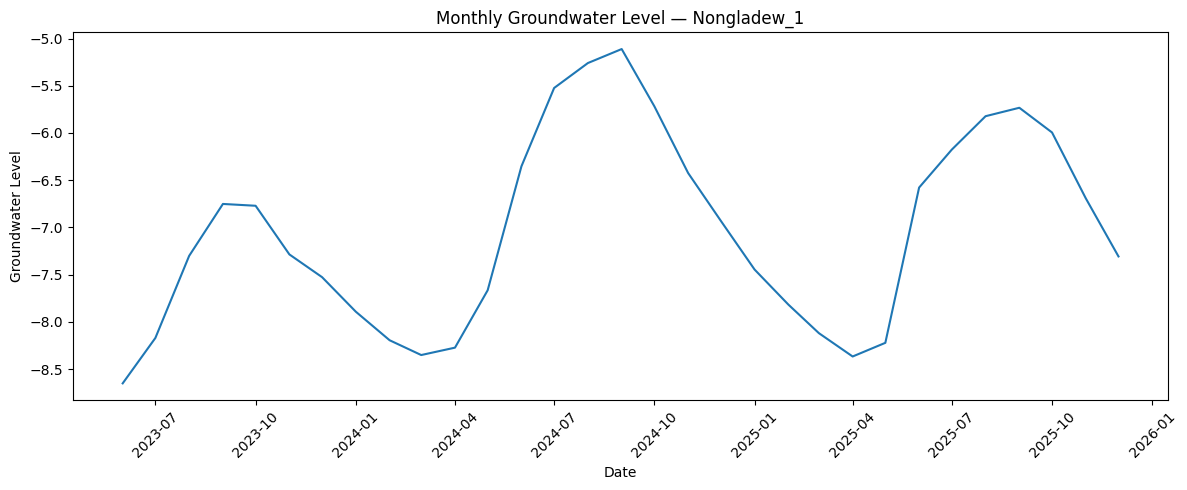

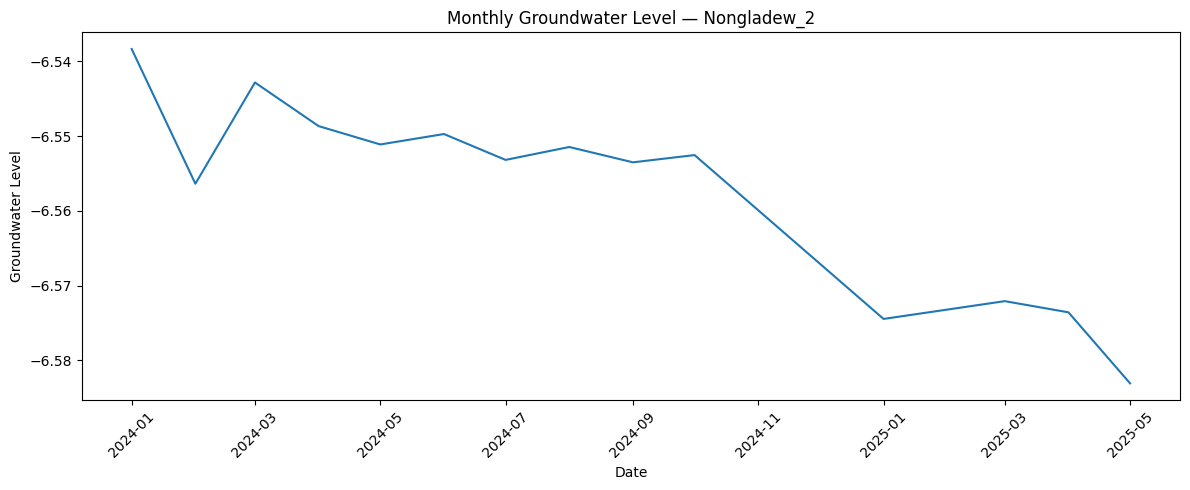

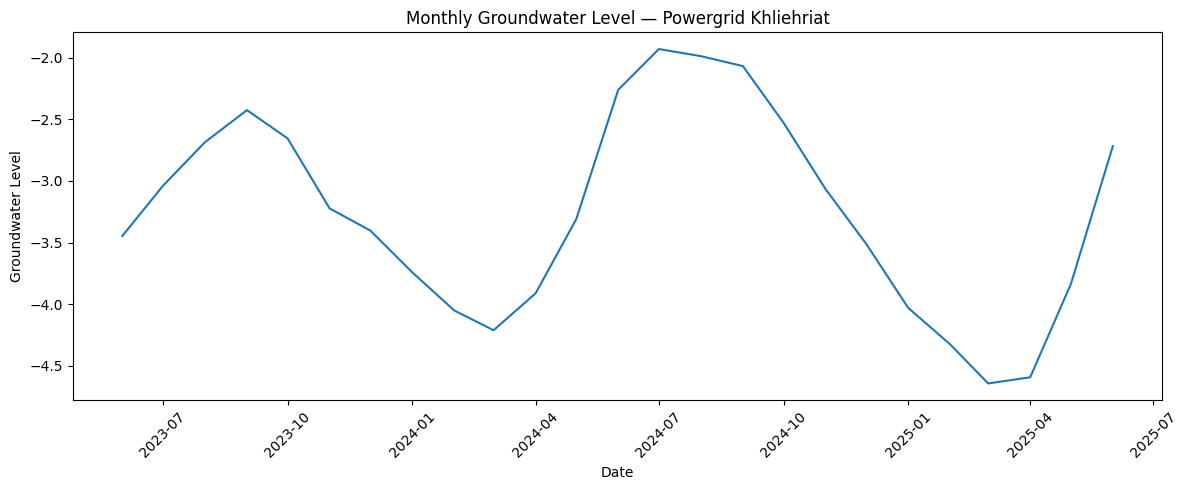

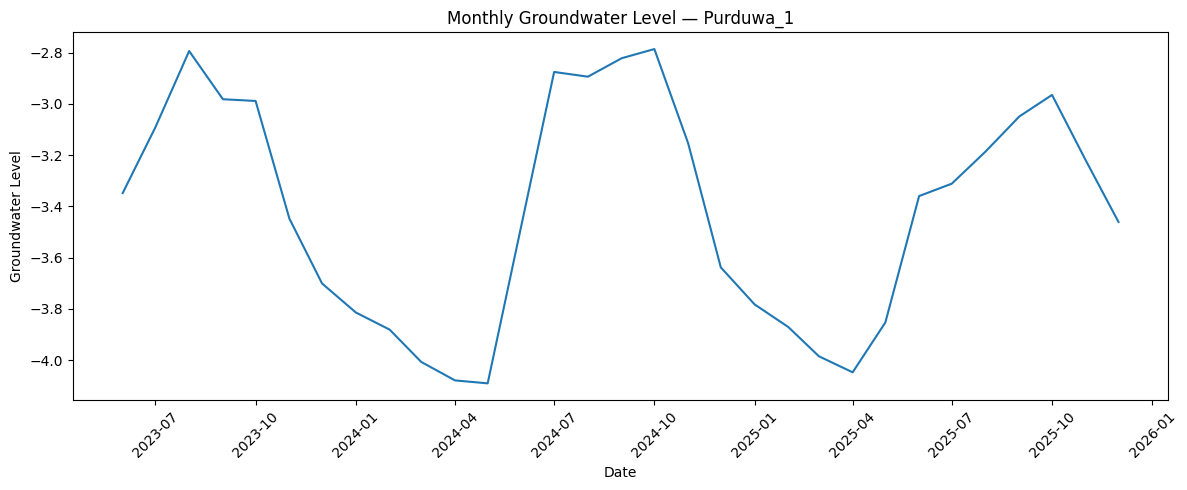

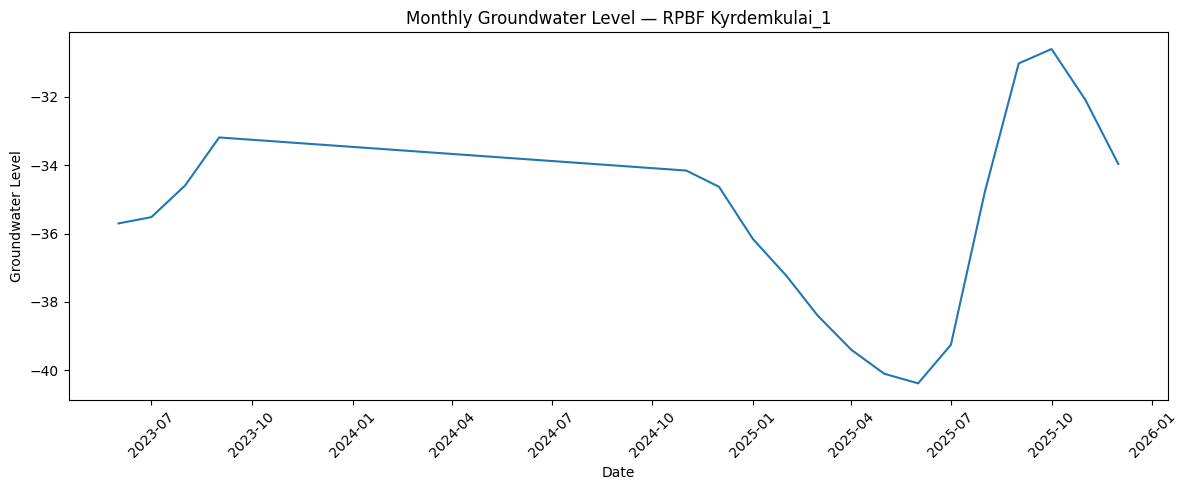

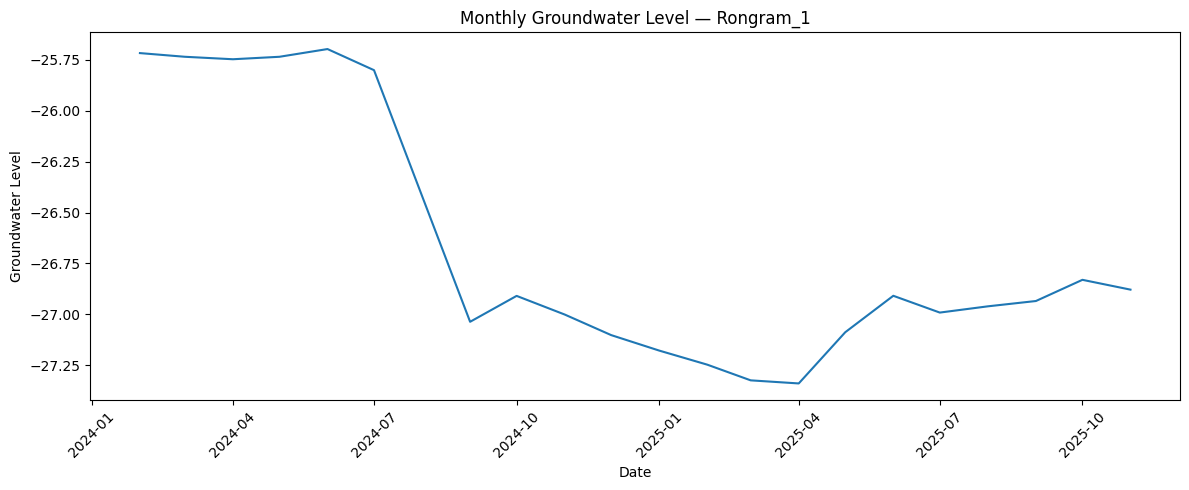

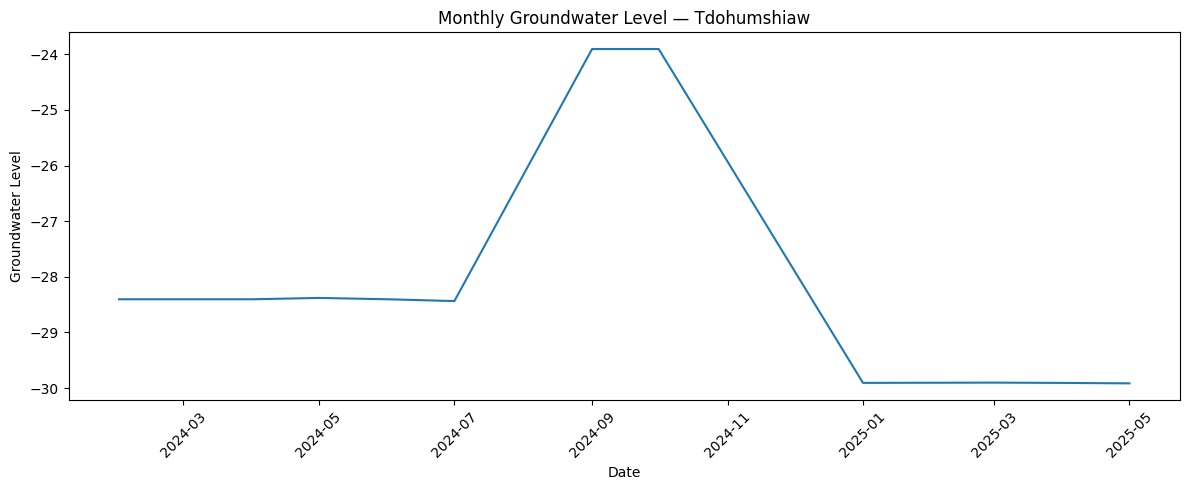

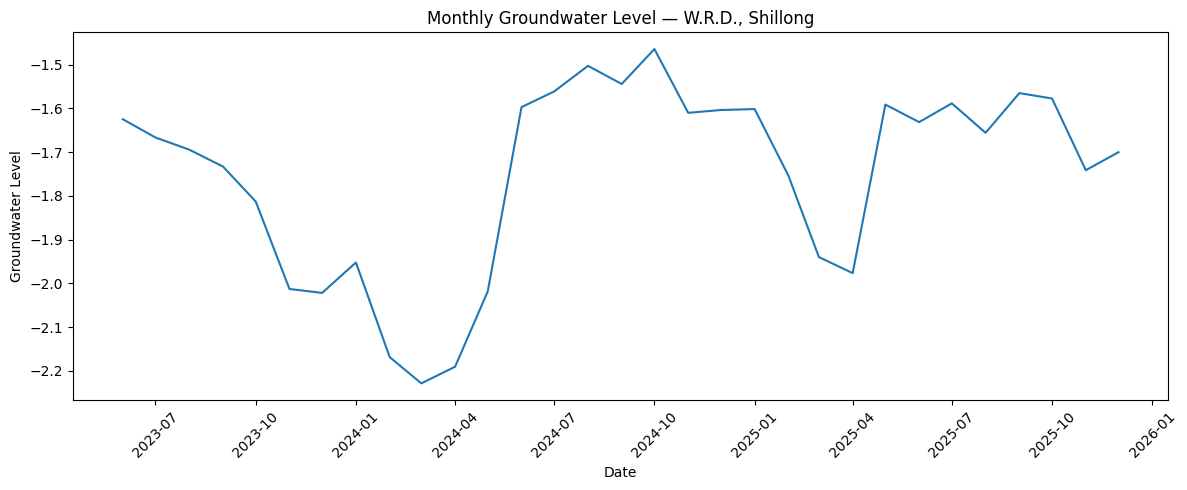

In [11]:
stations = monthly_df["Station"].unique()

for station in stations:
    station_data = monthly_df[
        monthly_df["Station"] == station
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        station_data["Timestamp"],
        station_data["Groundwater_Level_Final"]
    )

    plt.title(f"Monthly Groundwater Level — {station}")
    plt.xlabel("Date")
    plt.ylabel("Groundwater Level")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

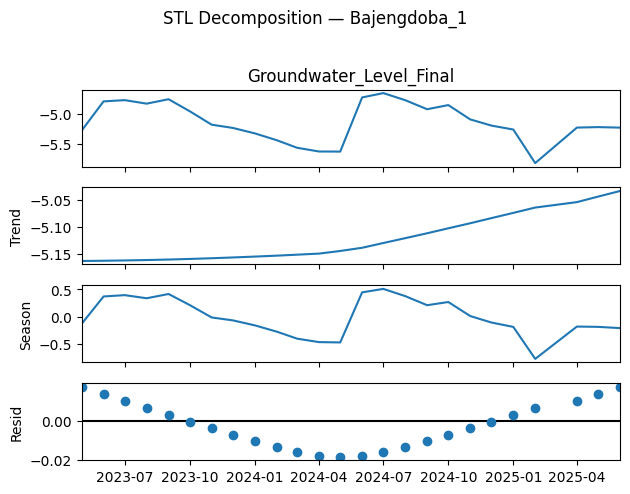

In [12]:
station = "Bajengdoba_1"

station_data = monthly_df[
    monthly_df["Station"] == station
].copy()

station_data = station_data.set_index("Timestamp")

stl = STL(
    station_data["Groundwater_Level_Final"],
    period=12,
    robust=True
)

result = stl.fit()

result.plot()

plt.suptitle(
    f"STL Decomposition — {station}",
    y=1.02
)

plt.tight_layout()
plt.show()

In [13]:
mk_result = mk.original_test(
    result.trend.dropna()
)

print(mk_result)

Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(2.886579864025407e-12), z=np.float64(6.9831355291288615), Tau=np.float64(1.0), s=np.float64(300.0), var_s=1833.3333333333333, slope=np.float64(0.005372945619192591), intercept=np.float64(-5.2092475797074576))


In [14]:
import pymannkendall as mk

station = "Bajengdoba_1"

station_data = monthly_df[
    monthly_df["Station"] == station
].copy()

station_data = station_data.sort_values("Timestamp")

values = station_data["Groundwater_Level_Final"].dropna()

mk_result = mk.original_test(values)

print("Station:", station)
print("Number of monthly observations:", len(values))
print()
print("Trend:", mk_result.trend)
print("p-value:", mk_result.p)
print("Kendall Tau:", mk_result.Tau)
print("Z:", mk_result.z)
print("Sen's slope:", mk_result.slope)

Station: Bajengdoba_1
Number of monthly observations: 25

Trend: no trend
p-value: 0.1289960116674873
Kendall Tau: -0.22
Z: -1.5180729411149698
Sen's slope: -0.01951400159175406


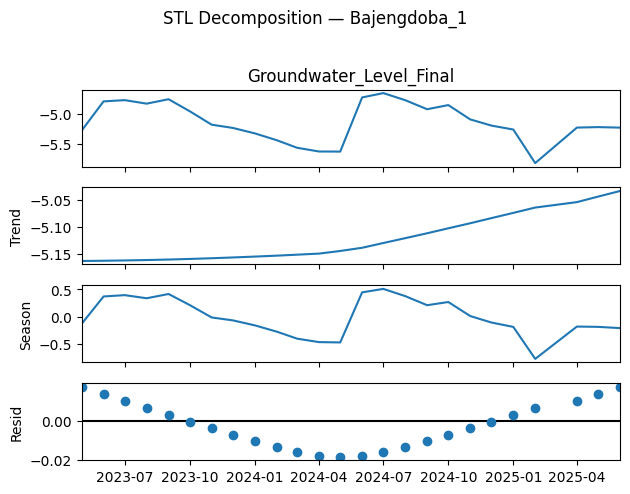

In [15]:
station_data = monthly_df[
    monthly_df["Station"] == "Bajengdoba_1"
].copy()

station_data = station_data.set_index("Timestamp")

stl = STL(
    station_data["Groundwater_Level_Final"],
    period=12,
    robust=True
)

result = stl.fit()

result.plot()

plt.suptitle(
    "STL Decomposition — Bajengdoba_1",
    y=1.02
)

plt.tight_layout()
plt.show()

In [16]:
results = []

for station in monthly_df["Station"].unique():

    station_data = monthly_df[
        monthly_df["Station"] == station
    ].copy()

    station_data = station_data.sort_values("Timestamp")

    values = station_data[
        "Groundwater_Level_Final"
    ].dropna()

    n_months = len(values)

    # -----------------------------
    # Mann-Kendall
    # -----------------------------
    if n_months >= 5:

        mk_result = mk.original_test(values)

        mk_trend = mk_result.trend
        mk_p = mk_result.p
        mk_tau = mk_result.Tau
        mk_z = mk_result.z
        sen_slope = mk_result.slope

    else:

        mk_trend = "Insufficient data"
        mk_p = np.nan
        mk_tau = np.nan
        mk_z = np.nan
        sen_slope = np.nan

    # -----------------------------
    # STL
    # -----------------------------
    # Annual STL requires approximately
    # two seasonal cycles = 24 months
    if n_months >= 24:

        try:

            stl = STL(
                values,
                period=12,
                robust=True
            )

            stl_result = stl.fit()

            stl_available = True

        except Exception:

            stl_available = False

    else:

        stl_available = False

    results.append({
        "Station": station,
        "Monthly_Observations": n_months,
        "STL_Available": stl_available,
        "MK_Trend": mk_trend,
        "MK_p_value": mk_p,
        "Kendall_Tau": mk_tau,
        "MK_Z": mk_z,
        "Sen_Slope": sen_slope
    })


trend_results = pd.DataFrame(results)

trend_results = trend_results.sort_values(
    "Station"
).reset_index(drop=True)

trend_results

,Station,Monthly_Observations,STL_Available,MK_Trend,MK_p_value,Kendall_Tau,MK_Z,Sen_Slope
0,Bajengdoba_1,25,True,no trend,0.128996,-0.220000,-1.518073,-0.019514
1,Chasingre (NEHU),5,False,no trend,0.086411,-0.800000,-1.714643,-0.005191
2,Dadenggre_1,23,False,increasing,0.000017,0.640316,4.294733,0.245455
3,Jengjal,10,False,no trend,0.126849,0.400000,1.526645,0.183845
4,Mendal_1,31,True,no trend,0.670857,0.055914,0.424972,0.002366
5,Mendipathar_1,23,False,increasing,0.000654,0.513834,3.408138,0.096218
6,NIT Cherrapunji,31,True,increasing,0.009782,0.329032,2.583455,0.034771
7,Nongladew_1,31,True,no trend,0.143826,0.187097,1.461692,0.037827
8,Nongladew_2,14,False,decreasing,0.000688,-0.692308,-3.394183,-0.002587
9,Powergrid Khliehriat,25,True,no trend,0.154258,-0.206667,-1.424653,-0.042988


In [17]:
print(trend_results.to_string(index=False))

             Station  Monthly_Observations  STL_Available   MK_Trend  MK_p_value  Kendall_Tau      MK_Z  Sen_Slope
        Bajengdoba_1                    25           True   no trend    0.128996    -0.220000 -1.518073  -0.019514
    Chasingre (NEHU)                     5          False   no trend    0.086411    -0.800000 -1.714643  -0.005191
         Dadenggre_1                    23          False increasing    0.000017     0.640316  4.294733   0.245455
             Jengjal                    10          False   no trend    0.126849     0.400000  1.526645   0.183845
            Mendal_1                    31           True   no trend    0.670857     0.055914  0.424972   0.002366
       Mendipathar_1                    23          False increasing    0.000654     0.513834  3.408138   0.096218
     NIT Cherrapunji                    31           True increasing    0.009782     0.329032  2.583455   0.034771
         Nongladew_1                    31           True   no trend    0.143826

In [18]:
trend_results["Significant"] = np.where(
    trend_results["MK_p_value"] < 0.05,
    "Yes",
    "No"
)

trend_results[
    [
        "Station",
        "Monthly_Observations",
        "MK_Trend",
        "MK_p_value",
        "Kendall_Tau",
        "Sen_Slope",
        "Significant"
    ]
]

,Station,Monthly_Observations,MK_Trend,MK_p_value,Kendall_Tau,Sen_Slope,Significant
0,Bajengdoba_1,25,no trend,0.128996,-0.220000,-0.019514,No
1,Chasingre (NEHU),5,no trend,0.086411,-0.800000,-0.005191,No
2,Dadenggre_1,23,increasing,0.000017,0.640316,0.245455,Yes
3,Jengjal,10,no trend,0.126849,0.400000,0.183845,No
4,Mendal_1,31,no trend,0.670857,0.055914,0.002366,No
5,Mendipathar_1,23,increasing,0.000654,0.513834,0.096218,Yes
6,NIT Cherrapunji,31,increasing,0.009782,0.329032,0.034771,Yes
7,Nongladew_1,31,no trend,0.143826,0.187097,0.037827,No
8,Nongladew_2,14,decreasing,0.000688,-0.692308,-0.002587,Yes
9,Powergrid Khliehriat,25,no trend,0.154258,-0.206667,-0.042988,No


In [19]:
stl_stations = trend_results[
    trend_results["STL_Available"] == True
]["Station"].tolist()

print("Stations suitable for annual STL:")
for station in stl_stations:
    print("-", station)

Stations suitable for annual STL:
- Bajengdoba_1
- Mendal_1
- NIT Cherrapunji
- Nongladew_1
- Powergrid Khliehriat
- Purduwa_1
- W.R.D., Shillong


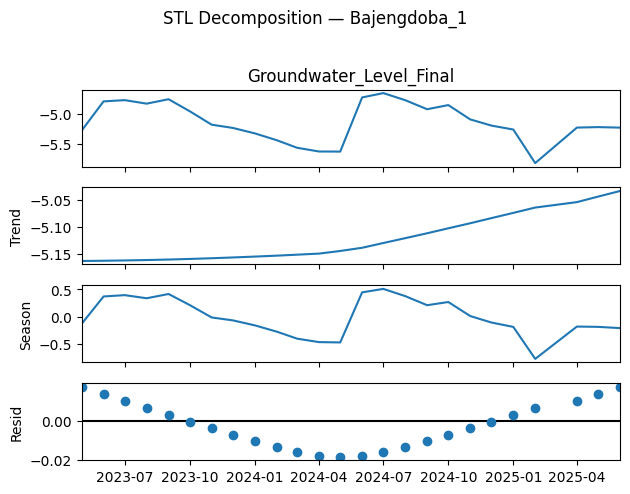

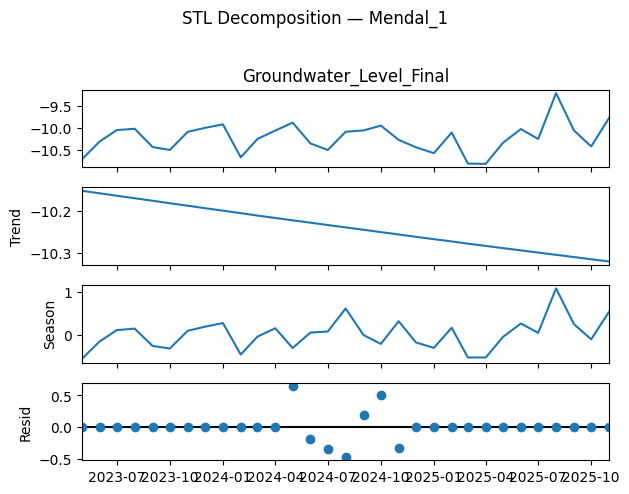

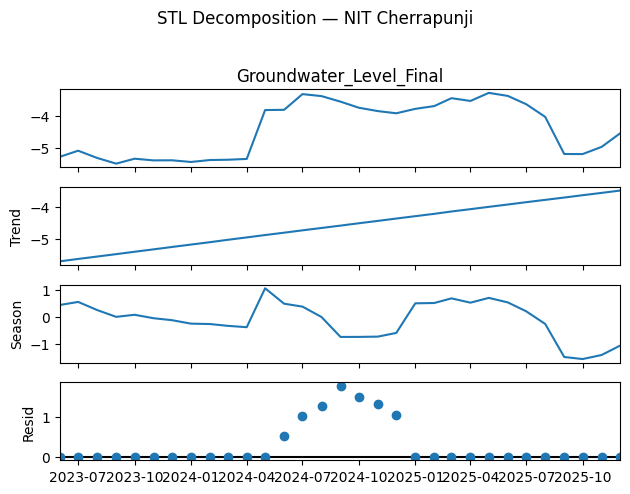

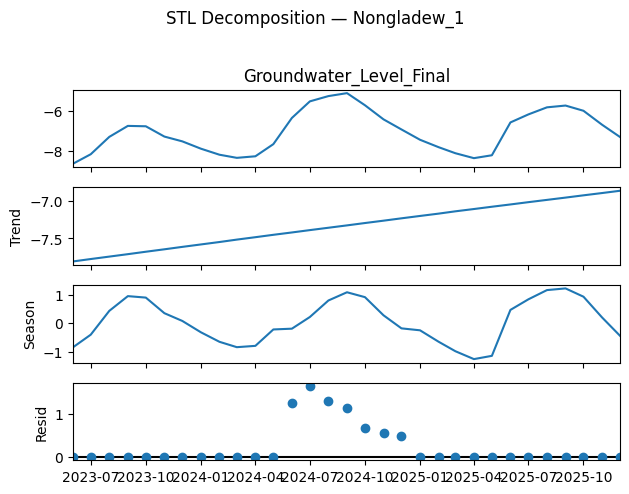

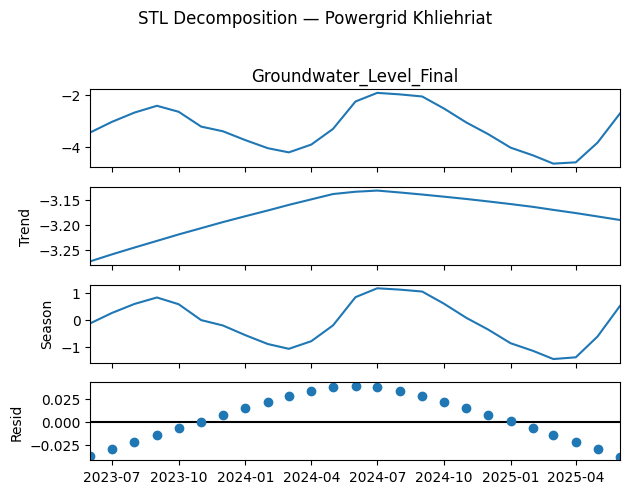

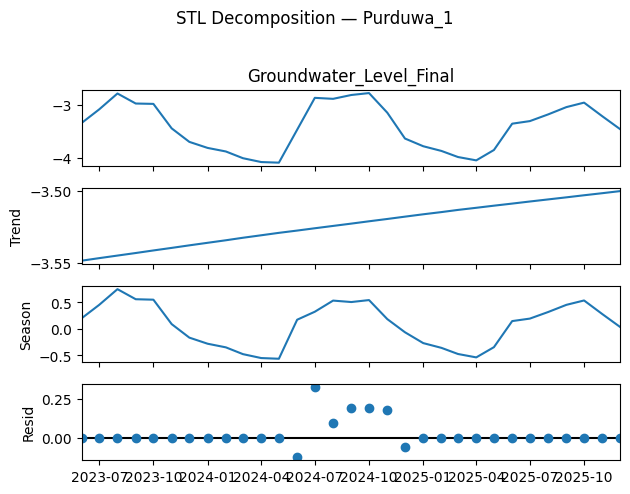

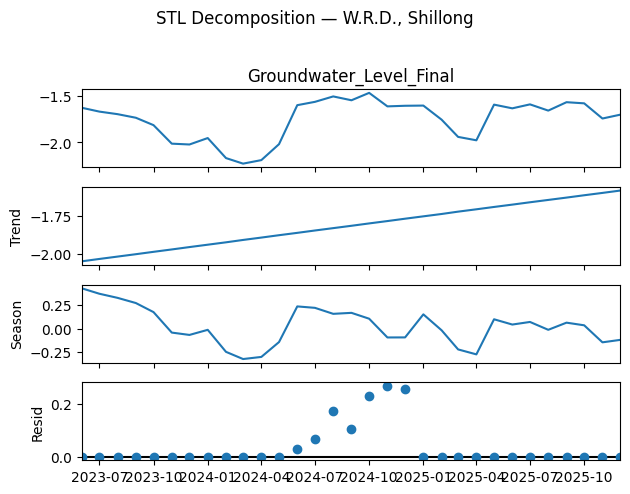

In [20]:
for station in stl_stations:

    station_data = monthly_df[
        monthly_df["Station"] == station
    ].copy()

    station_data = station_data.sort_values("Timestamp")
    station_data = station_data.set_index("Timestamp")

    stl = STL(
        station_data["Groundwater_Level_Final"],
        period=12,
        robust=True
    )

    result = stl.fit()

    result.plot()

    plt.suptitle(
        f"STL Decomposition — {station}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/sih/groundwater_clean_final.csv")

# Convert timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Sort properly
df = df.sort_values(["Station", "Timestamp"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nStations:", df["Station"].nunique())

print("\nMissing values:")
print(df["Groundwater_Level_Final"].isna().sum())

print("\nDuplicate Station-Timestamp records:")
print(df.duplicated(["Station", "Timestamp"]).sum())

df.head()

Dataset shape: (36117, 4)

Columns:
['Station', 'Timestamp', 'Groundwater_Level_Final', 'Quality_Flag']

Stations: 15

Missing values:
5127

Duplicate Station-Timestamp records:
0


,Station,Timestamp,Groundwater_Level_Final,Quality_Flag
0,Bajengdoba_1,2023-05-04 18:00:00,-5.51,OK
1,Bajengdoba_1,2023-05-05 00:00:00,-5.52,OK
2,Bajengdoba_1,2023-05-05 06:00:00,-5.49,OK
3,Bajengdoba_1,2023-05-05 12:00:00,-5.51,OK
4,Bajengdoba_1,2023-05-05 18:00:00,-5.46,OK


In [22]:
# Keep only observations with an actual groundwater value
ml_df = df.dropna(subset=["Groundwater_Level_Final"]).copy()

print("ML dataset shape:", ml_df.shape)

print("\nRecords per station:")
print(ml_df["Station"].value_counts())

print("\nDate range:")
print(ml_df["Timestamp"].min(), "to", ml_df["Timestamp"].max())

ML dataset shape: (30990, 4)

Records per station:
Station
W.R.D., Shillong        3264
Purduwa_1               3236
NIT Cherrapunji         3234
Nongladew_1             3220
Powergrid Khliehriat    2580
Bajengdoba_1            2486
Mendipathar_1           2266
Mendal_1                2139
Rongram_1               2100
RPBF Kyrdemkulai_1      1603
Dadenggre_1             1598
Nongladew_2             1308
Jengjal                  880
Tdohumshiaw              868
Chasingre (NEHU)         208
Name: count, dtype: int64

Date range:
2023-05-01 00:00:00 to 2025-12-31 18:00:00


In [23]:
ml_df["Year"] = ml_df["Timestamp"].dt.year
ml_df["Month"] = ml_df["Timestamp"].dt.month
ml_df["Day"] = ml_df["Timestamp"].dt.day
ml_df["DayOfYear"] = ml_df["Timestamp"].dt.dayofyear
ml_df["Hour"] = ml_df["Timestamp"].dt.hour

# Cyclic time features
ml_df["Month_sin"] = np.sin(2 * np.pi * ml_df["Month"] / 12)
ml_df["Month_cos"] = np.cos(2 * np.pi * ml_df["Month"] / 12)

ml_df["Hour_sin"] = np.sin(2 * np.pi * ml_df["Hour"] / 24)
ml_df["Hour_cos"] = np.cos(2 * np.pi * ml_df["Hour"] / 24)

ml_df.head()

,Station,Timestamp,Groundwater_Level_Final,Quality_Flag,Year,Month,Day,DayOfYear,Hour,Month_sin,Month_cos,Hour_sin,Hour_cos
0,Bajengdoba_1,2023-05-04 18:00:00,-5.51,OK,2023,5,4,124,18,0.5,-0.866025,-1.000000e+00,-1.836970e-16
1,Bajengdoba_1,2023-05-05 00:00:00,-5.52,OK,2023,5,5,125,0,0.5,-0.866025,0.000000e+00,1.000000e+00
2,Bajengdoba_1,2023-05-05 06:00:00,-5.49,OK,2023,5,5,125,6,0.5,-0.866025,1.000000e+00,6.123234e-17
3,Bajengdoba_1,2023-05-05 12:00:00,-5.51,OK,2023,5,5,125,12,0.5,-0.866025,1.224647e-16,-1.000000e+00
4,Bajengdoba_1,2023-05-05 18:00:00,-5.46,OK,2023,5,5,125,18,0.5,-0.866025,-1.000000e+00,-1.836970e-16


In [24]:
# ============================================================
# CREATE LAG FEATURES FOR GROUNDWATER FORECASTING
# ============================================================

# Make sure data is sorted correctly
ml_df = ml_df.sort_values(
    ["Station", "Timestamp"]
).reset_index(drop=True)

# Previous groundwater observations
ml_df["Lag_1"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(1)
ml_df["Lag_2"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(2)
ml_df["Lag_3"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(3)
ml_df["Lag_4"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(4)

# Longer-term lags
ml_df["Lag_7"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(7)
ml_df["Lag_12"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(12)
ml_df["Lag_24"] = ml_df.groupby("Station")["Groundwater_Level_Final"].shift(24)

print("Lag features created.")

print(
    ml_df[
        [
            "Station",
            "Timestamp",
            "Groundwater_Level_Final",
            "Lag_1",
            "Lag_2",
            "Lag_3",
            "Lag_4",
            "Lag_7",
            "Lag_12",
            "Lag_24"
        ]
    ].head(15)
)

Lag features created.
         Station           Timestamp  Groundwater_Level_Final  Lag_1  Lag_2  \
0   Bajengdoba_1 2023-05-04 18:00:00                    -5.51    NaN    NaN   
1   Bajengdoba_1 2023-05-05 00:00:00                    -5.52  -5.51    NaN   
2   Bajengdoba_1 2023-05-05 06:00:00                    -5.49  -5.52  -5.51   
3   Bajengdoba_1 2023-05-05 12:00:00                    -5.51  -5.49  -5.52   
4   Bajengdoba_1 2023-05-05 18:00:00                    -5.46  -5.51  -5.49   
5   Bajengdoba_1 2023-05-06 00:00:00                    -5.48  -5.46  -5.51   
6   Bajengdoba_1 2023-05-06 06:00:00                    -5.45  -5.48  -5.46   
7   Bajengdoba_1 2023-05-06 12:00:00                    -5.49  -5.45  -5.48   
8   Bajengdoba_1 2023-05-06 18:00:00                    -5.44  -5.49  -5.45   
9   Bajengdoba_1 2023-05-07 00:00:00                    -5.46  -5.44  -5.49   
10  Bajengdoba_1 2023-05-07 06:00:00                    -5.44  -5.46  -5.44   
11  Bajengdoba_1 2023-05-07 12

In [25]:
# ============================================================
# ROLLING FEATURES
# ============================================================

grouped = ml_df.groupby("Station")["Groundwater_Level_Final"]

ml_df["Rolling_Mean_6"] = (
    grouped.transform(lambda x: x.shift(1).rolling(6).mean())
)

ml_df["Rolling_Std_6"] = (
    grouped.transform(lambda x: x.shift(1).rolling(6).std())
)

ml_df["Rolling_Mean_12"] = (
    grouped.transform(lambda x: x.shift(1).rolling(12).mean())
)

ml_df["Rolling_Mean_24"] = (
    grouped.transform(lambda x: x.shift(1).rolling(24).mean())
)

print("Rolling features created.")


Rolling features created.


In [26]:
# ============================================================
# TARGET
# ============================================================

# Target = next groundwater observation
ml_df["Target"] = (
    ml_df.groupby("Station")["Groundwater_Level_Final"].shift(-1)
)

print("Target created.")

print(
    ml_df[
        [
            "Station",
            "Timestamp",
            "Groundwater_Level_Final",
            "Lag_1",
            "Lag_2",
            "Rolling_Mean_6",
            "Target"
        ]
    ].head(15)
)

Target created.
         Station           Timestamp  Groundwater_Level_Final  Lag_1  Lag_2  \
0   Bajengdoba_1 2023-05-04 18:00:00                    -5.51    NaN    NaN   
1   Bajengdoba_1 2023-05-05 00:00:00                    -5.52  -5.51    NaN   
2   Bajengdoba_1 2023-05-05 06:00:00                    -5.49  -5.52  -5.51   
3   Bajengdoba_1 2023-05-05 12:00:00                    -5.51  -5.49  -5.52   
4   Bajengdoba_1 2023-05-05 18:00:00                    -5.46  -5.51  -5.49   
5   Bajengdoba_1 2023-05-06 00:00:00                    -5.48  -5.46  -5.51   
6   Bajengdoba_1 2023-05-06 06:00:00                    -5.45  -5.48  -5.46   
7   Bajengdoba_1 2023-05-06 12:00:00                    -5.49  -5.45  -5.48   
8   Bajengdoba_1 2023-05-06 18:00:00                    -5.44  -5.49  -5.45   
9   Bajengdoba_1 2023-05-07 00:00:00                    -5.46  -5.44  -5.49   
10  Bajengdoba_1 2023-05-07 06:00:00                    -5.44  -5.46  -5.44   
11  Bajengdoba_1 2023-05-07 12:00:00

In [27]:
# ============================================================
# FINAL ML DATASET
# ============================================================

feature_columns = [
    "Year",
    "Month",
    "Day",
    "DayOfYear",
    "Hour",
    "Month_sin",
    "Month_cos",
    "Hour_sin",
    "Hour_cos",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_4",
    "Lag_7",
    "Lag_12",
    "Lag_24",
    "Rolling_Mean_6",
    "Rolling_Std_6",
    "Rolling_Mean_12",
    "Rolling_Mean_24"
]

target_column = "Target"

model_df = ml_df.dropna(
    subset=feature_columns + [target_column]
).copy()

print("Final ML dataset shape:", model_df.shape)

print("\nFeatures:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Final ML dataset shape: (30615, 25)

Features:
['Year', 'Month', 'Day', 'DayOfYear', 'Hour', 'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4', 'Lag_7', 'Lag_12', 'Lag_24', 'Rolling_Mean_6', 'Rolling_Std_6', 'Rolling_Mean_12', 'Rolling_Mean_24']

Target:
Target


In [28]:
print("\nMissing values in ML features:")
print(model_df[feature_columns].isna().sum())

print("\nMissing target values:")
print(model_df[target_column].isna().sum())

print("\nFinal ML dataset:")
display(
    model_df[
        ["Station", "Timestamp",
         "Groundwater_Level_Final",
         "Lag_1", "Lag_2",
         "Rolling_Mean_6",
         "Target"]
    ].head(10)
)


Missing values in ML features:
Year               0
Month              0
Day                0
DayOfYear          0
Hour               0
Month_sin          0
Month_cos          0
Hour_sin           0
Hour_cos           0
Lag_1              0
Lag_2              0
Lag_3              0
Lag_4              0
Lag_7              0
Lag_12             0
Lag_24             0
Rolling_Mean_6     0
Rolling_Std_6      0
Rolling_Mean_12    0
Rolling_Mean_24    0
dtype: int64

Missing target values:
0

Final ML dataset:


,Station,Timestamp,Groundwater_Level_Final,Lag_1,Lag_2,Rolling_Mean_6,Target
24,Bajengdoba_1,2023-05-10 18:00:00,-5.52,-5.51,-5.49,-5.490000,-5.51
25,Bajengdoba_1,2023-05-11 00:00:00,-5.51,-5.52,-5.51,-5.498333,-5.52
26,Bajengdoba_1,2023-05-11 06:00:00,-5.52,-5.51,-5.52,-5.500000,-5.53
27,Bajengdoba_1,2023-05-11 12:00:00,-5.53,-5.52,-5.51,-5.505000,-5.55
28,Bajengdoba_1,2023-05-11 18:00:00,-5.55,-5.53,-5.52,-5.513333,-5.53
29,Bajengdoba_1,2023-05-12 00:00:00,-5.53,-5.55,-5.53,-5.523333,-5.55
30,Bajengdoba_1,2023-05-12 06:00:00,-5.55,-5.53,-5.55,-5.526667,-5.55
31,Bajengdoba_1,2023-05-12 12:00:00,-5.55,-5.55,-5.53,-5.531667,-5.57
32,Bajengdoba_1,2023-05-12 18:00:00,-5.57,-5.55,-5.55,-5.538333,-5.55
33,Bajengdoba_1,2023-05-13 00:00:00,-5.55,-5.57,-5.55,-5.546667,-5.58


In [29]:
# ============================================================
# CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# Sort by time
model_df = model_df.sort_values(
    ["Timestamp", "Station"]
).reset_index(drop=True)

# 80% training, 20% testing
split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df  = model_df.iloc[split_index:].copy()

print("Total ML records:", len(model_df))
print("Training records:", len(train_df))
print("Testing records :", len(test_df))

print("\nTraining period:")
print(train_df["Timestamp"].min(), "to", train_df["Timestamp"].max())

print("\nTesting period:")
print(test_df["Timestamp"].min(), "to", test_df["Timestamp"].max())

Total ML records: 30615
Training records: 24492
Testing records : 6123

Training period:
2023-05-07 00:00:00 to 2025-04-25 12:00:00

Testing period:
2025-04-25 18:00:00 to 2025-12-31 12:00:00


In [30]:
# ============================================================
# CHECK TEMPORAL LEAKAGE
# ============================================================

print("Latest training timestamp:")
print(train_df["Timestamp"].max())

print("\nEarliest testing timestamp:")
print(test_df["Timestamp"].min())

if train_df["Timestamp"].max() < test_df["Timestamp"].min():
    print("\n✓ No temporal overlap between train and test.")
else:
    print("\n⚠️ Check the split.")

Latest training timestamp:
2025-04-25 12:00:00

Earliest testing timestamp:
2025-04-25 18:00:00

✓ No temporal overlap between train and test.


In [31]:
# ============================================================
# CREATE X AND y
# ============================================================

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (24492, 20)
y_train: (24492,)
X_test : (6123, 20)
y_test : (6123,)


In [32]:
# ============================================================
# STEP 1: TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Make sure data is sorted correctly
ml_df = ml_df.sort_values(["Station", "Timestamp"]).reset_index(drop=True)

# Features and target
feature_cols = [
    'Year', 'Month', 'Day', 'DayOfYear', 'Hour',
    'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
    'Lag_7', 'Lag_12', 'Lag_24',
    'Rolling_Mean_6', 'Rolling_Std_6',
    'Rolling_Mean_12', 'Rolling_Mean_24'
]

target_col = 'Target'

# ------------------------------------------------------------
# Use chronological split
# First 80% = training
# Last 20% = testing
# ------------------------------------------------------------

split_index = int(len(ml_df) * 0.80)

train_df = ml_df.iloc[:split_index].copy()
test_df  = ml_df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_df["Timestamp"].min(), "to", train_df["Timestamp"].max())

print("\nTesting period:")
print(test_df["Timestamp"].min(), "to", test_df["Timestamp"].max())

print("\nFeature shape:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTarget shape:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Training samples: 24792
Testing samples: 6198

Training period:
2023-05-01 00:00:00 to 2025-12-31 18:00:00

Testing period:
2023-06-07 12:00:00 to 2025-12-31 18:00:00

Feature shape:
X_train: (24792, 20)
X_test : (6198, 20)

Target shape:
y_train: (24792,)
y_test : (6198,)


In [33]:
# ============================================================
# TIME-BASED TRAIN / TEST SPLIT
# ============================================================

# Sort chronologically within each station
ml_df = ml_df.sort_values(
    ['Station', 'Timestamp']
).reset_index(drop=True)

# Features and target
feature_cols = [
    'Year', 'Month', 'Day', 'DayOfYear', 'Hour',
    'Month_sin', 'Month_cos', 'Hour_sin', 'Hour_cos',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_4',
    'Lag_7', 'Lag_12', 'Lag_24',
    'Rolling_Mean_6', 'Rolling_Std_6',
    'Rolling_Mean_12', 'Rolling_Mean_24'
]

target_col = 'Target'

# ------------------------------------------------------------
# IMPORTANT:
# Use a GLOBAL chronological split.
# ------------------------------------------------------------

# Sort the complete ML dataset by timestamp
ml_df = ml_df.sort_values('Timestamp').reset_index(drop=True)

split_index = int(len(ml_df) * 0.80)

train_df = ml_df.iloc[:split_index].copy()
test_df  = ml_df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_df['Timestamp'].min(), "to", train_df['Timestamp'].max())

print("\nTesting period:")
print(test_df['Timestamp'].min(), "to", test_df['Timestamp'].max())

print("\nFeature shape:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTarget shape:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Training samples: 24792
Testing samples: 6198

Training period:
2023-05-01 00:00:00 to 2025-04-23 06:00:00

Testing period:
2025-04-23 06:00:00 to 2025-12-31 18:00:00

Feature shape:
X_train: (24792, 20)
X_test : (6198, 20)

Target shape:
y_train: (24792,)
y_test : (6198,)


In [34]:
print("Train max:", train_df['Timestamp'].max())
print("Test min :", test_df['Timestamp'].min())

print(
    "Overlap:",
    len(set(train_df['Timestamp']).intersection(set(test_df['Timestamp'])))
)

Train max: 2025-04-23 06:00:00
Test min : 2025-04-23 06:00:00
Overlap: 1


In [35]:
# Remove the overlapping boundary timestamp from TEST
test_df = test_df[test_df['Timestamp'] > train_df['Timestamp'].max()].copy()

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(train_df['Timestamp'].min(), "to", train_df['Timestamp'].max())

print("\nTesting period:")
print(test_df['Timestamp'].min(), "to", test_df['Timestamp'].max())

print("\nTrain max:", train_df['Timestamp'].max())
print("Test min :", test_df['Timestamp'].min())
print("Overlap:", len(
    set(train_df['Timestamp']).intersection(set(test_df['Timestamp']))
))

Training samples: 24792
Testing samples: 6195

Training period:
2023-05-01 00:00:00 to 2025-04-23 06:00:00

Testing period:
2025-04-23 12:00:00 to 2025-12-31 18:00:00

Train max: 2025-04-23 06:00:00
Test min : 2025-04-23 12:00:00
Overlap: 0


In [36]:
# ============================================================
# CHECK NaN VALUES BEFORE MODEL TRAINING
# ============================================================

print("NaN values in X_train:", X_train.isna().sum().sum())
print("NaN values in X_test :", X_test.isna().sum().sum())
print("NaN values in y_train:", y_train.isna().sum())
print("NaN values in y_test :", y_test.isna().sum())

print("\nInfinite values:")
print("X_train:", np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())
print("X_test :", np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

print("\nTarget dtype:")
print("y_train:", y_train.dtype)
print("y_test :", y_test.dtype)

NaN values in X_train: 1515
NaN values in X_test : 0
NaN values in y_train: 0
NaN values in y_test : 15

Infinite values:
X_train: 0
X_test : 0

Target dtype:
y_train: float64
y_test : float64


In [37]:
# ============================================================
# REMOVE ROWS WITH MISSING TARGET
# ============================================================

valid_test = y_test.notna()

X_test = X_test.loc[valid_test].copy()
y_test = y_test.loc[valid_test].copy()

# Keep test_df aligned as well
test_df = test_df.loc[valid_test].copy()

print("After removing missing targets:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Missing X_test:", X_test.isna().sum().sum())
print("Missing y_test:", y_test.isna().sum())

After removing missing targets:
X_test: (6180, 20)
y_test: (6180,)
Missing X_test: 0
Missing y_test: 0


In [38]:
# ============================================================
# MODEL 1: RANDOM FOREST REGRESSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd
import time

# ------------------------------------------------------------
# 1. Create Random Forest model
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# 2. Train
# ------------------------------------------------------------

start_time = time.time()

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time

# ------------------------------------------------------------
# 3. Predict
# ------------------------------------------------------------

y_pred_rf = rf_model.predict(X_test)

# ------------------------------------------------------------
# 4. Evaluation
# ------------------------------------------------------------

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

# MAPE can be problematic when actual values are close to zero.
# We calculate it only where y_test != 0.
non_zero = y_test != 0

mape_rf = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_rf[non_zero])
        / y_test[non_zero]
    )
) * 100

print("=" * 60)
print("RANDOM FOREST REGRESSION RESULTS")
print("=" * 60)

print(f"MAE  : {mae_rf:.6f}")
print(f"RMSE : {rmse_rf:.6f}")
print(f"R²   : {r2_rf:.6f}")
print(f"MAPE : {mape_rf:.4f}%")
print(f"Training time: {training_time:.2f} seconds")

RANDOM FOREST REGRESSION RESULTS
MAE  : 0.317180
RMSE : 1.189652
R²   : 0.990424
MAPE : 4.2071%
Training time: 62.98 seconds


In [39]:
# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

rf_results = test_df[
    ['Station', 'Timestamp', 'Groundwater_Level_Final', 'Target']
].copy()

rf_results['Predicted'] = y_pred_rf

print("\nSample predictions:")
display(rf_results.head(20))


Sample predictions:


,Station,Timestamp,Groundwater_Level_Final,Target,Predicted
24795,Mendipathar_1,2025-04-23 12:00:00,-9.835,-9.858,-9.865565
24796,Dadenggre_1,2025-04-23 12:00:00,-3.141,-3.147,-3.193710
24797,Rongram_1,2025-04-23 12:00:00,-27.279,-27.292,-27.306990
24798,NIT Cherrapunji,2025-04-23 12:00:00,-3.380,-3.400,-3.415810
24799,Nongladew_1,2025-04-23 12:00:00,-8.390,-8.390,-8.398800
24800,Purduwa_1,2025-04-23 12:00:00,-4.010,-4.020,-4.009300
24801,"W.R.D., Shillong",2025-04-23 12:00:00,-1.790,-1.840,-1.822350
24802,Powergrid Khliehriat,2025-04-23 12:00:00,-4.510,-4.510,-4.539200
24803,RPBF Kyrdemkulai_1,2025-04-23 12:00:00,-40.317,-39.549,-39.479845
24804,Dadenggre_1,2025-04-23 18:00:00,-3.147,-3.149,-3.150510


In [40]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)

print("\nFeature Importance:")
display(feature_importance)


Feature Importance:


,Feature,Importance
0,Lag_1,0.904618
1,Rolling_Mean_6,0.069317
2,Lag_2,0.010552
3,Lag_3,0.005930
4,Lag_7,0.002601
5,Lag_12,0.001680
6,Lag_4,0.000996
7,Rolling_Mean_12,0.000980
8,Rolling_Std_6,0.000877
9,Lag_24,0.000510


In [41]:
# ============================================================
# MODEL 2: XGBOOST REGRESSION
# ============================================================

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import time

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time_xgb = time.time() - start_time

# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------

y_pred_xgb = xgb_model.predict(X_test)

# ------------------------------------------------------------
# Evaluate
# ------------------------------------------------------------

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

non_zero = y_test != 0

mape_xgb = np.mean(
    np.abs(
        (y_test[non_zero] - y_pred_xgb[non_zero])
        / y_test[non_zero]
    )
) * 100

print("=" * 60)
print("XGBOOST REGRESSION RESULTS")
print("=" * 60)

print(f"MAE  : {mae_xgb:.6f}")
print(f"RMSE : {rmse_xgb:.6f}")
print(f"R²   : {r2_xgb:.6f}")
print(f"MAPE : {mape_xgb:.4f}%")
print(f"Training time: {training_time_xgb:.2f} seconds")

XGBOOST REGRESSION RESULTS
MAE  : 0.229342
RMSE : 0.774583
R²   : 0.995941
MAPE : 3.9064%
Training time: 5.20 seconds


In [42]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE
# ============================================================

xgb_feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
).reset_index(drop=True)

print("XGBoost Feature Importance:")
display(xgb_feature_importance)

XGBoost Feature Importance:


,Feature,Importance
0,Lag_1,0.500820
1,Lag_2,0.314559
2,Rolling_Mean_6,0.118804
3,Lag_3,0.024428
4,Rolling_Mean_12,0.021884
5,Lag_4,0.006923
6,Rolling_Std_6,0.003267
7,Lag_7,0.002013
8,Lag_12,0.001555
9,Year,0.001226


In [43]:
# ============================================================
# XGBOOST SAMPLE PREDICTIONS
# ============================================================

xgb_results = test_df[
    ['Station', 'Timestamp', 'Groundwater_Level_Final', 'Target']
].copy()

xgb_results['Predicted'] = y_pred_xgb

display(xgb_results.head(20))

,Station,Timestamp,Groundwater_Level_Final,Target,Predicted
24795,Mendipathar_1,2025-04-23 12:00:00,-9.835,-9.858,-9.888468
24796,Dadenggre_1,2025-04-23 12:00:00,-3.141,-3.147,-3.178176
24797,Rongram_1,2025-04-23 12:00:00,-27.279,-27.292,-27.339701
24798,NIT Cherrapunji,2025-04-23 12:00:00,-3.380,-3.400,-3.411547
24799,Nongladew_1,2025-04-23 12:00:00,-8.390,-8.390,-8.380020
24800,Purduwa_1,2025-04-23 12:00:00,-4.010,-4.020,-4.019454
24801,"W.R.D., Shillong",2025-04-23 12:00:00,-1.790,-1.840,-1.809538
24802,Powergrid Khliehriat,2025-04-23 12:00:00,-4.510,-4.510,-4.577725
24803,RPBF Kyrdemkulai_1,2025-04-23 12:00:00,-40.317,-39.549,-39.385429
24804,Dadenggre_1,2025-04-23 18:00:00,-3.147,-3.149,-3.152245


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ============================================================
# NAIVE PERSISTENCE BASELINE
# Target at t+1 predicted as groundwater level at t
# ============================================================

# Lag_1 is already the previous groundwater observation
y_pred_naive = X_test["Lag_1"].values

mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
r2_naive = r2_score(y_test, y_pred_naive)

# Avoid division by zero
nonzero = np.abs(y_test.values) > 1e-10

mape_naive = np.mean(
    np.abs(
        (y_test.values[nonzero] - y_pred_naive[nonzero])
        / y_test.values[nonzero]
    )
) * 100

print("=" * 60)
print("NAIVE PERSISTENCE BASELINE RESULTS")
print("=" * 60)
print(f"MAE  : {mae_naive:.6f}")
print(f"RMSE : {rmse_naive:.6f}")
print(f"R²   : {r2_naive:.6f}")
print(f"MAPE : {mape_naive:.4f}%")

NAIVE PERSISTENCE BASELINE RESULTS
MAE  : 0.161174
RMSE : 0.811540
R²   : 0.995544
MAPE : 3.5941%


In [45]:
# ============================================================
# MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Naive Persistence",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_naive,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_naive,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_naive,
        r2_rf,
        r2_xgb
    ],
    "MAPE (%)": [
        mape_naive,
        mape_rf,
        mape_xgb
    ]
})

print(comparison.round(6))

               Model       MAE      RMSE        R2  MAPE (%)
0  Naive Persistence  0.161174  0.811540  0.995544  3.594075
1      Random Forest  0.317180  1.189652  0.990424  4.207133
2            XGBoost  0.229342  0.774583  0.995941  3.906385


In [46]:
# ============================================================
# IMPROVEMENT OVER NAIVE BASELINE
# ============================================================

mae_improvement = (
    (mae_naive - mae_xgb) / mae_naive
) * 100

rmse_improvement = (
    (rmse_naive - rmse_xgb) / rmse_naive
) * 100

print("\n" + "=" * 60)
print("XGBOOST IMPROVEMENT OVER NAIVE BASELINE")
print("=" * 60)

print(f"MAE improvement : {mae_improvement:.2f}%")
print(f"RMSE improvement: {rmse_improvement:.2f}%")


XGBOOST IMPROVEMENT OVER NAIVE BASELINE
MAE improvement : -42.29%
RMSE improvement: 4.55%


In [47]:
# ============================================================
# XGBOOST - FINAL EVALUATION
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Generate predictions
# ------------------------------------------------------------
y_pred_xgb = xgb_model.predict(X_test)

# ------------------------------------------------------------
# 2. Safety check
# ------------------------------------------------------------
print("X_test samples :", len(X_test))
print("y_test samples :", len(y_test))
print("Predictions    :", len(y_pred_xgb))

assert len(y_test) == len(y_pred_xgb), \
    "y_test and predictions have different lengths!"

# ------------------------------------------------------------
# 3. Calculate metrics
# ------------------------------------------------------------
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# MAPE
y_test_array = np.asarray(y_test)

nonzero_mask = y_test_array != 0

mape_xgb = np.mean(
    np.abs(
        (y_test_array[nonzero_mask] -
         y_pred_xgb[nonzero_mask])
        / y_test_array[nonzero_mask]
    )
) * 100

print("\n" + "=" * 60)
print("XGBOOST FINAL RESULTS")
print("=" * 60)
print(f"MAE  : {mae_xgb:.6f}")
print(f"RMSE : {rmse_xgb:.6f}")
print(f"R²   : {r2_xgb:.6f}")
print(f"MAPE : {mape_xgb:.4f}%")

# ------------------------------------------------------------
# 4. Create prediction table
# ------------------------------------------------------------

# Use the indices of the cleaned X_test
prediction_results = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_xgb
}, index=X_test.index)

print("\nSample predictions:")
display(prediction_results.head(20))

X_test samples : 6180
y_test samples : 6180
Predictions    : 6180

XGBOOST FINAL RESULTS
MAE  : 0.229342
RMSE : 0.774583
R²   : 0.995941
MAPE : 3.9064%

Sample predictions:


,Actual,Predicted
24795,-9.858,-9.888468
24796,-3.147,-3.178176
24797,-27.292,-27.339701
24798,-3.400,-3.411547
24799,-8.390,-8.380020
24800,-4.020,-4.019454
24801,-1.840,-1.809538
24802,-4.510,-4.577725
24803,-39.549,-39.385429
24804,-3.149,-3.152245


XGBOOST RESIDUAL SUMMARY
Mean Residual       : 0.009550
Std Residual        : 0.774587
Mean Absolute Error : 0.229342
Max Absolute Error  : 16.754947


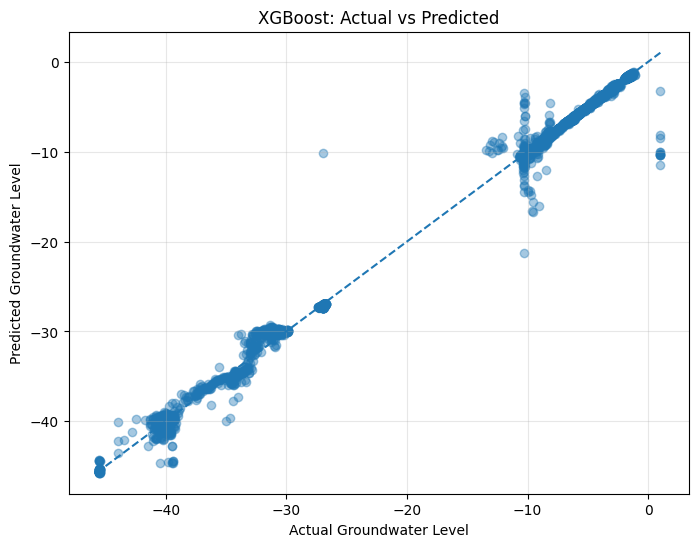

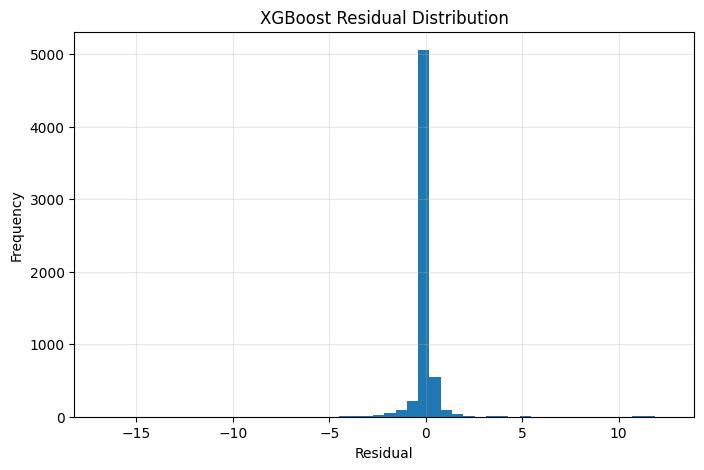

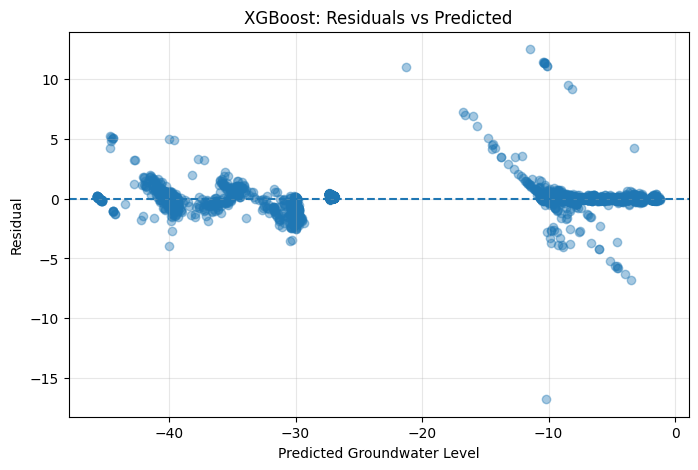

In [48]:
# ============================================================
# XGBOOST MODEL DIAGNOSTICS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create results dataframe
# ------------------------------------------------------------

results = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": np.asarray(y_pred_xgb)
})

results["Residual"] = results["Actual"] - results["Predicted"]
results["Absolute_Error"] = np.abs(results["Residual"])

print("=" * 60)
print("XGBOOST RESIDUAL SUMMARY")
print("=" * 60)

print(f"Mean Residual       : {results['Residual'].mean():.6f}")
print(f"Std Residual        : {results['Residual'].std():.6f}")
print(f"Mean Absolute Error : {results['Absolute_Error'].mean():.6f}")
print(f"Max Absolute Error  : {results['Absolute_Error'].max():.6f}")

# ------------------------------------------------------------
# 2. Actual vs Predicted
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    results["Actual"],
    results["Predicted"],
    alpha=0.4
)

min_val = min(results["Actual"].min(), results["Predicted"].min())
max_val = max(results["Actual"].max(), results["Predicted"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Groundwater Level")
plt.ylabel("Predicted Groundwater Level")
plt.title("XGBoost: Actual vs Predicted")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 3. Residual distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    results["Residual"],
    bins=50
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("XGBoost Residual Distribution")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 4. Residual vs Predicted
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    results["Predicted"],
    results["Residual"],
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Groundwater Level")
plt.ylabel("Residual")
plt.title("XGBoost: Residuals vs Predicted")
plt.grid(alpha=0.3)
plt.show()

In [49]:
# ============================================================
# XGBOOST — STATION-WISE PERFORMANCE
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# Build test results dataframe
# ------------------------------------------------------------

# IMPORTANT:
# Replace `test_df` below with the dataframe containing the
# Station column corresponding to X_test/y_test if your
# station information is stored under another variable name.

station_results = pd.DataFrame({
    "Station": test_df.loc[y_test.index, "Station"].values,
    "Actual": np.asarray(y_test),
    "Predicted": np.asarray(y_pred_xgb)
})

# ------------------------------------------------------------
# Calculate metrics for each station
# ------------------------------------------------------------

station_metrics = []

for station, group in station_results.groupby("Station"):

    actual = group["Actual"].values
    predicted = group["Predicted"].values

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # R² can fail for a station with constant actual values
    if len(np.unique(actual)) > 1:
        r2 = r2_score(actual, predicted)
    else:
        r2 = np.nan

    # Avoid division by zero
    nonzero = actual != 0

    if np.any(nonzero):
        mape = np.mean(
            np.abs(
                (actual[nonzero] - predicted[nonzero])
                / actual[nonzero]
            )
        ) * 100
    else:
        mape = np.nan

    station_metrics.append({
        "Station": station,
        "Samples": len(group),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    })

station_metrics = pd.DataFrame(station_metrics)

# Sort by MAE
station_metrics = station_metrics.sort_values("MAE")

print("=" * 80)
print("XGBOOST STATION-WISE PERFORMANCE")
print("=" * 80)

display(
    station_metrics.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
        "MAPE (%)": "{:.2f}"
    })
)

# ------------------------------------------------------------
# Best and worst stations
# ------------------------------------------------------------

best_station = station_metrics.iloc[0]
worst_station = station_metrics.iloc[-1]

print("\n" + "=" * 80)
print("BEST PERFORMING STATION")
print("=" * 80)

print(f"Station : {best_station['Station']}")
print(f"MAE     : {best_station['MAE']:.4f}")
print(f"RMSE    : {best_station['RMSE']:.4f}")
print(f"R²      : {best_station['R2']:.4f}")
print(f"MAPE    : {best_station['MAPE (%)']:.2f}%")

print("\n" + "=" * 80)
print("WORST PERFORMING STATION")
print("=" * 80)

print(f"Station : {worst_station['Station']}")
print(f"MAE     : {worst_station['MAE']:.4f}")
print(f"RMSE    : {worst_station['RMSE']:.4f}")
print(f"R²      : {worst_station['R2']:.4f}")
print(f"MAPE    : {worst_station['MAPE (%)']:.2f}%")

XGBOOST STATION-WISE PERFORMANCE


,Station,Samples,MAE,RMSE,R2,MAPE (%)
8,Nongladew_2,31,0.0246,0.0289,-0.4177,0.37
10,Purduwa_1,733,0.0306,0.0645,0.9590,0.96
0,Bajengdoba_1,99,0.0329,0.0399,-0.9051,0.63
2,Dadenggre_1,591,0.0381,0.0614,0.8250,1.40
6,NIT Cherrapunji,728,0.0492,0.0669,0.9926,1.20
14,"W.R.D., Shillong",770,0.0497,0.0687,0.7493,3.13
7,Nongladew_1,760,0.0561,0.0787,0.9906,0.88
13,Tdohumshiaw,27,0.0773,0.0935,-10.6048,0.26
9,Powergrid Khliehriat,87,0.0893,0.1473,0.9024,2.66
3,Jengjal,31,0.0908,0.1081,-12.3978,1.06



BEST PERFORMING STATION
Station : Nongladew_2
MAE     : 0.0246
RMSE    : 0.0289
R²      : -0.4177
MAPE    : 0.37%

WORST PERFORMING STATION
Station : RPBF Kyrdemkulai_1
MAE     : 0.8244
RMSE    : 1.1250
R²      : 0.9196
MAPE    : 2.36%


In [50]:
# Show dataframe variables currently available
import pandas as pd

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(name, obj.shape, list(obj.columns))

RuntimeError: dictionary changed size during iteration

In [51]:
# ============================================================
# XGBOOST — FINAL STATION-WISE PERFORMANCE
# ============================================================

print("=" * 80)
print("XGBOOST STATION-WISE PERFORMANCE")
print("=" * 80)

display(
    station_metrics.sort_values("MAE").style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
        "MAPE (%)": "{:.2f}"
    })
)

# Best and worst stations
best_station = station_metrics.loc[
    station_metrics["MAE"].idxmin()
]

worst_station = station_metrics.loc[
    station_metrics["MAE"].idxmax()
]

print("\n" + "=" * 80)
print("BEST PERFORMING STATION")
print("=" * 80)

print(f"Station : {best_station['Station']}")
print(f"Samples : {best_station['Samples']}")
print(f"MAE     : {best_station['MAE']:.4f}")
print(f"RMSE    : {best_station['RMSE']:.4f}")
print(f"R²      : {best_station['R2']:.4f}")
print(f"MAPE    : {best_station['MAPE (%)']:.2f}%")

print("\n" + "=" * 80)
print("WORST PERFORMING STATION")
print("=" * 80)

print(f"Station : {worst_station['Station']}")
print(f"Samples : {worst_station['Samples']}")
print(f"MAE     : {worst_station['MAE']:.4f}")
print(f"RMSE    : {worst_station['RMSE']:.4f}")
print(f"R²      : {worst_station['R2']:.4f}")
print(f"MAPE    : {worst_station['MAPE (%)']:.2f}%")

XGBOOST STATION-WISE PERFORMANCE


,Station,Samples,MAE,RMSE,R2,MAPE (%)
8,Nongladew_2,31,0.0246,0.0289,-0.4177,0.37
10,Purduwa_1,733,0.0306,0.0645,0.9590,0.96
0,Bajengdoba_1,99,0.0329,0.0399,-0.9051,0.63
2,Dadenggre_1,591,0.0381,0.0614,0.8250,1.40
6,NIT Cherrapunji,728,0.0492,0.0669,0.9926,1.20
14,"W.R.D., Shillong",770,0.0497,0.0687,0.7493,3.13
7,Nongladew_1,760,0.0561,0.0787,0.9906,0.88
13,Tdohumshiaw,27,0.0773,0.0935,-10.6048,0.26
9,Powergrid Khliehriat,87,0.0893,0.1473,0.9024,2.66
3,Jengjal,31,0.0908,0.1081,-12.3978,1.06



BEST PERFORMING STATION
Station : Nongladew_2
Samples : 31
MAE     : 0.0246
RMSE    : 0.0289
R²      : -0.4177
MAPE    : 0.37%

WORST PERFORMING STATION
Station : RPBF Kyrdemkulai_1
Samples : 761
MAE     : 0.8244
RMSE    : 1.1250
R²      : 0.9196
MAPE    : 2.36%


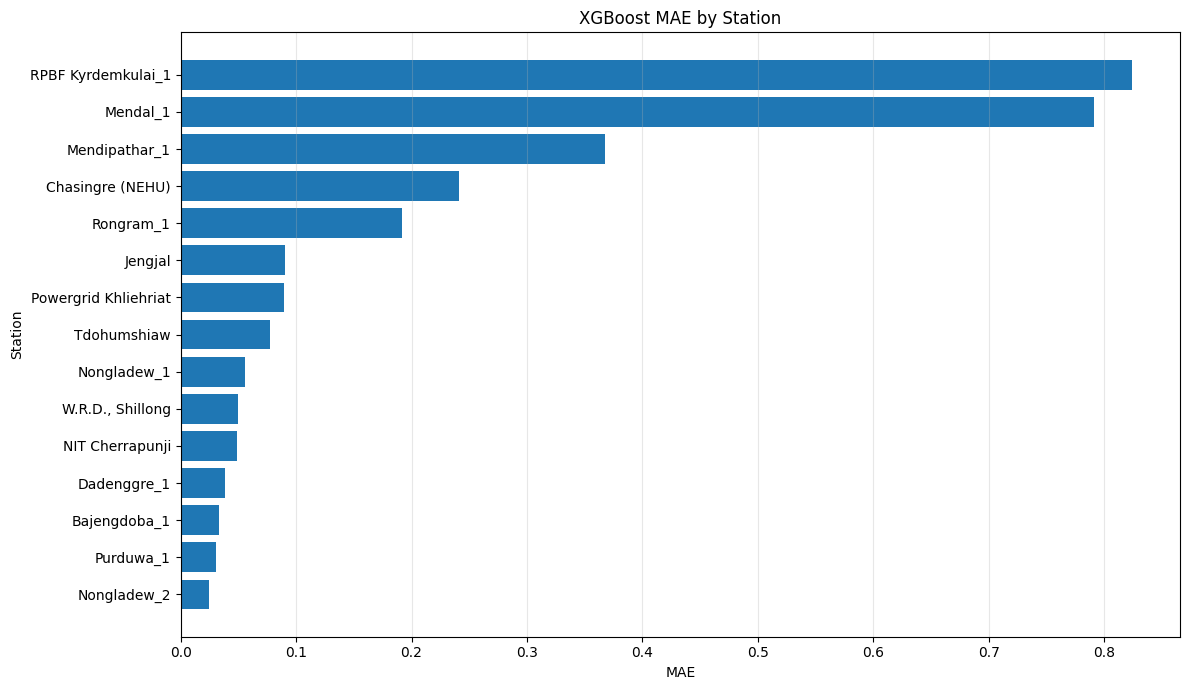

In [52]:
# ============================================================
# STATION-WISE MAE
# ============================================================

import matplotlib.pyplot as plt

plot_df = station_metrics.sort_values("MAE")

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["Station"],
    plot_df["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("Station")
plt.title("XGBoost MAE by Station")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

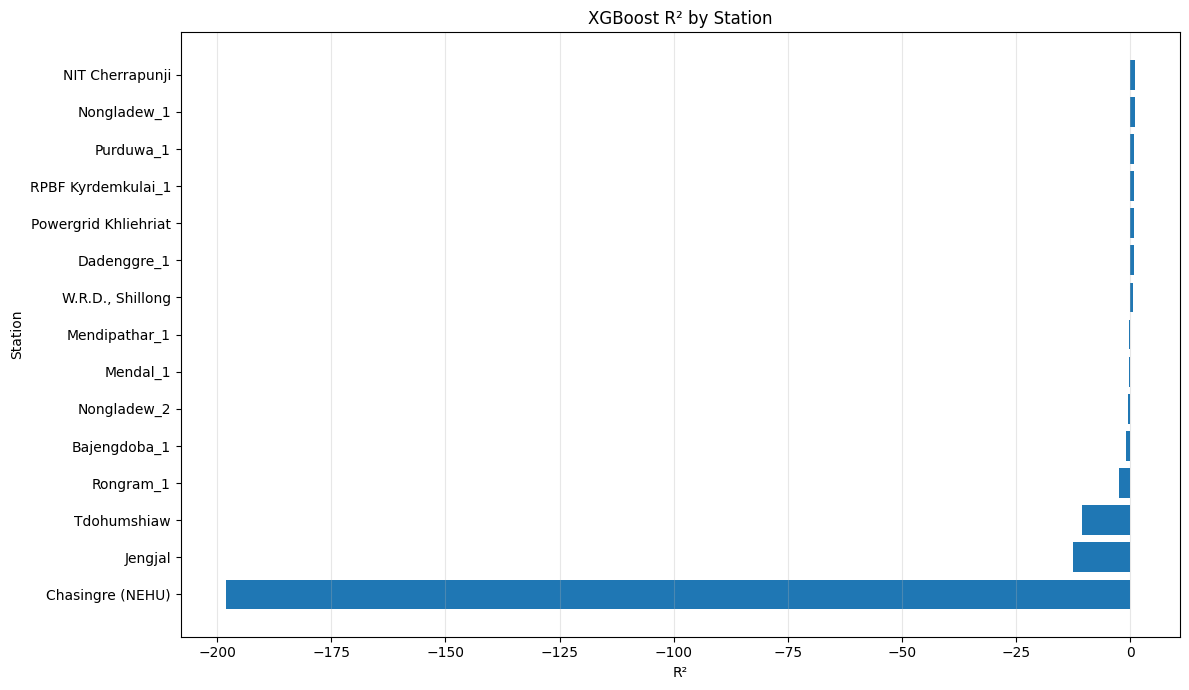

In [53]:
# ============================================================
# STATION-WISE R²
# ============================================================

plot_df = station_metrics.sort_values("R2")

plt.figure(figsize=(12, 7))

plt.barh(
    plot_df["Station"],
    plot_df["R2"]
)

plt.xlabel("R²")
plt.ylabel("Station")
plt.title("XGBoost R² by Station")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

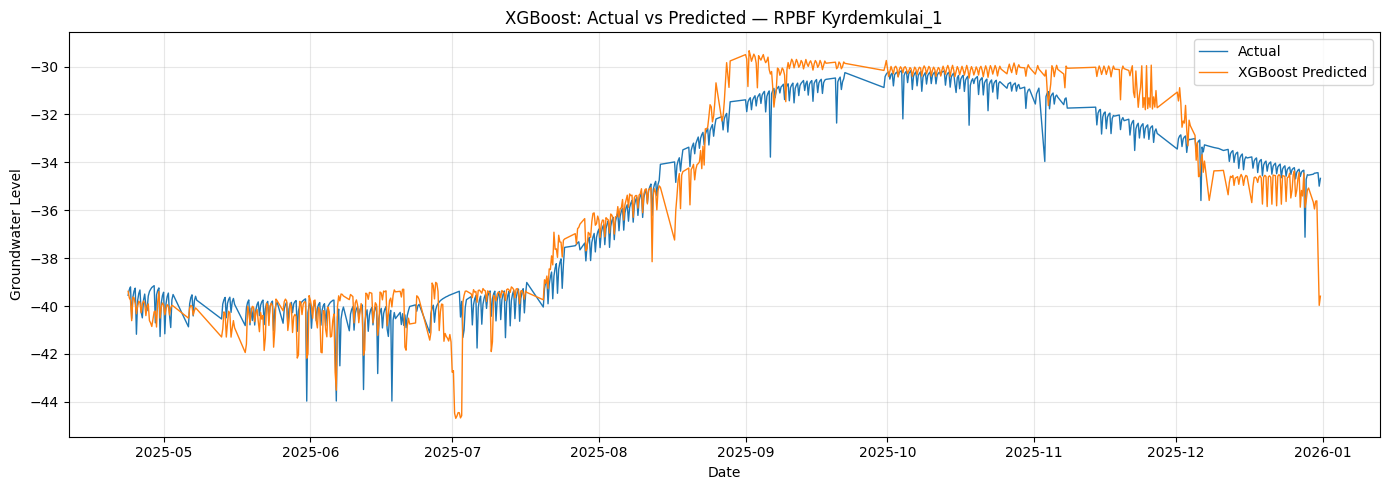

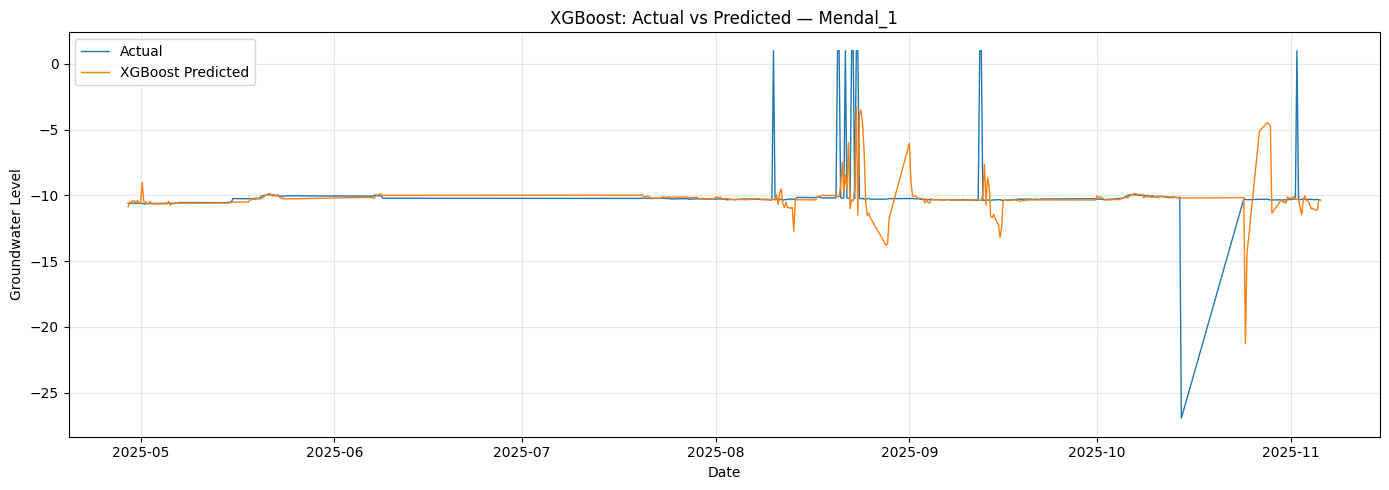

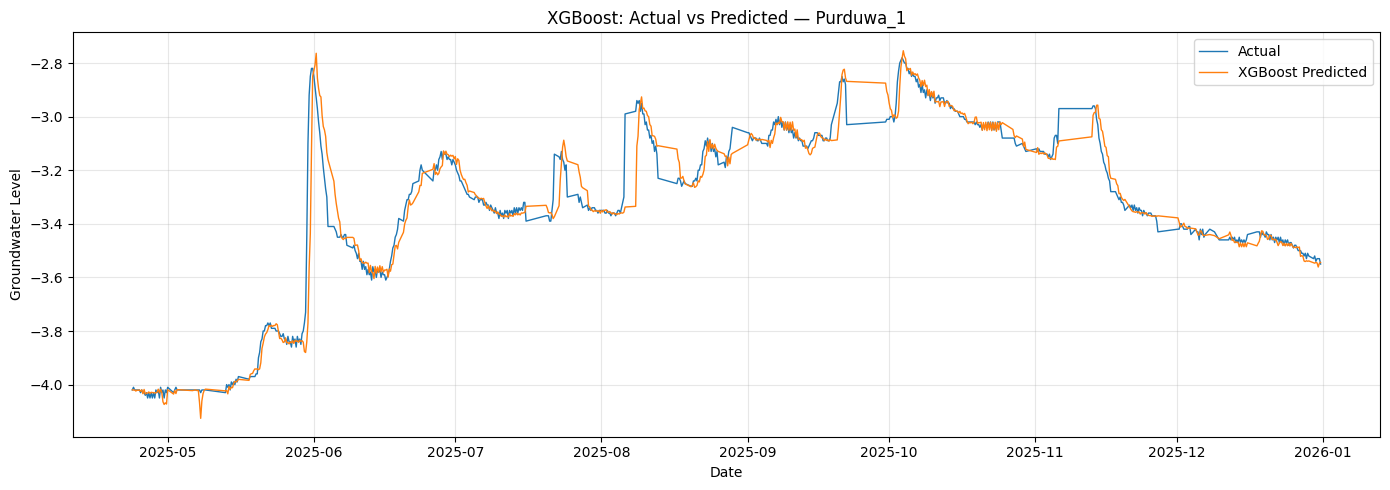

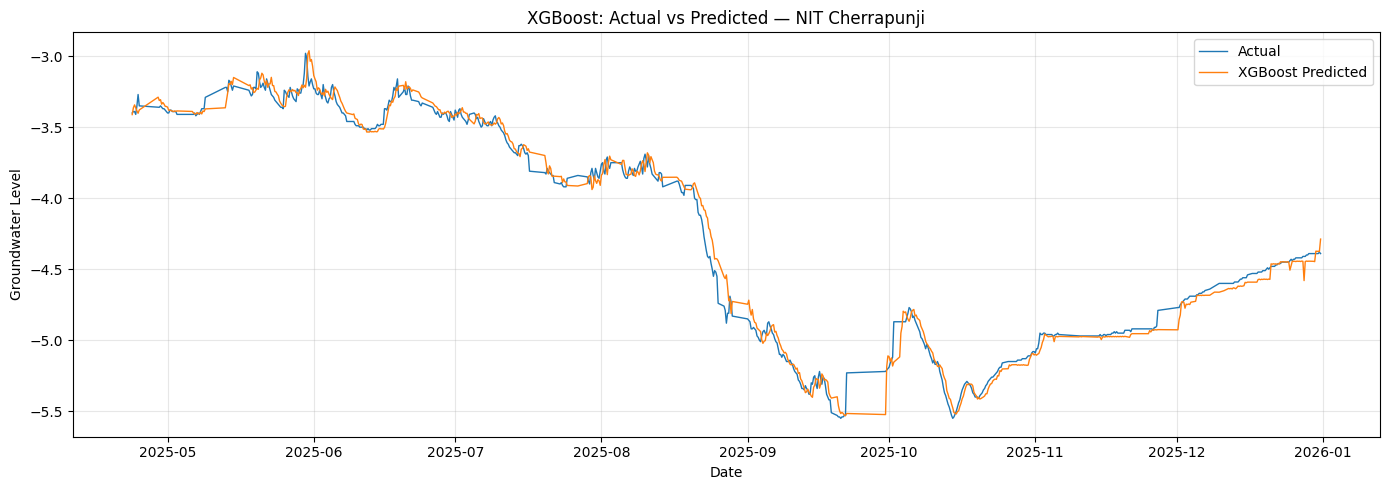

In [54]:
# ============================================================
# XGBOOST — ACTUAL VS PREDICTED OVER TIME
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Make a copy
plot_results = xgb_results.copy()

# Ensure timestamp is datetime
plot_results["Timestamp"] = pd.to_datetime(
    plot_results["Timestamp"]
)

# ------------------------------------------------------------
# Select a few important stations
# ------------------------------------------------------------

stations_to_plot = [
    "RPBF Kyrdemkulai_1",
    "Mendal_1",
    "Purduwa_1",
    "NIT Cherrapunji"
]

for station in stations_to_plot:

    station_plot = plot_results[
        plot_results["Station"] == station
    ].sort_values("Timestamp")

    if len(station_plot) == 0:
        print(f"No test data found for {station}")
        continue

    plt.figure(figsize=(14, 5))

    plt.plot(
        station_plot["Timestamp"],
        station_plot["Target"],
        label="Actual",
        linewidth=1
    )

    plt.plot(
        station_plot["Timestamp"],
        station_plot["Predicted"],
        label="XGBoost Predicted",
        linewidth=1
    )

    plt.xlabel("Date")
    plt.ylabel("Groundwater Level")
    plt.title(
        f"XGBoost: Actual vs Predicted — {station}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

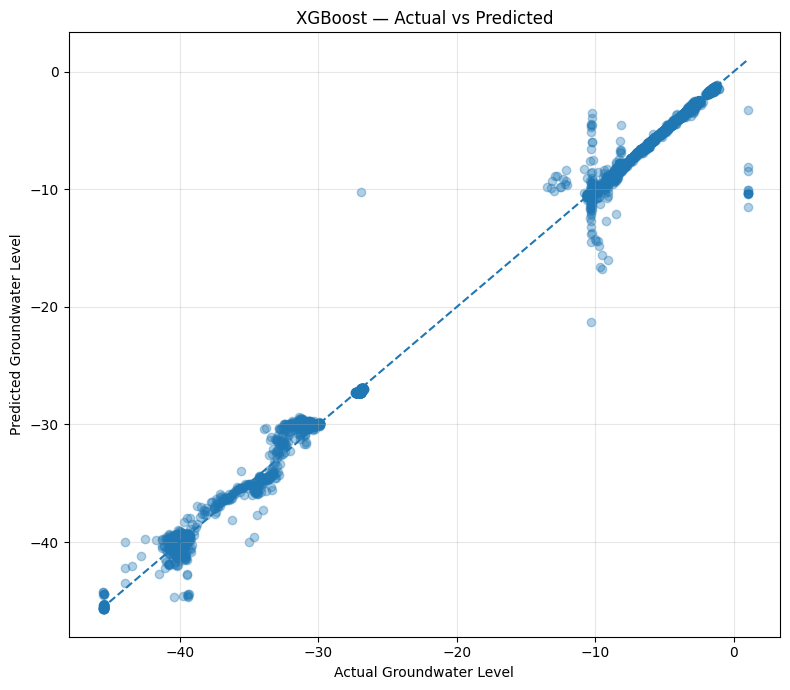

In [55]:
# ============================================================
# OVERALL ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 7))

plt.scatter(
    xgb_results["Target"],
    xgb_results["Predicted"],
    alpha=0.35
)

min_val = min(
    xgb_results["Target"].min(),
    xgb_results["Predicted"].min()
)

max_val = max(
    xgb_results["Target"].max(),
    xgb_results["Predicted"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Groundwater Level")
plt.ylabel("Predicted Groundwater Level")
plt.title("XGBoost — Actual vs Predicted")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# ============================================================
# MODEL 3 — LIGHTGBM REGRESSION
# ============================================================

import numpy as np
import pandas as pd
import time

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Import LightGBM
# ------------------------------------------------------------
try:
    from lightgbm import LGBMRegressor
except ImportError:
    !pip install lightgbm -q
    from lightgbm import LGBMRegressor


# ------------------------------------------------------------
# 2. Verify data
# ------------------------------------------------------------
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train.isna().sum().sum())
print("X_test :", X_test.isna().sum().sum())
print("y_train:", y_train.isna().sum())
print("y_test :", y_test.isna().sum())


# ------------------------------------------------------------
# 3. Train LightGBM
# ------------------------------------------------------------
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

start_time = time.time()

lgb_model.fit(
    X_train,
    y_train
)

training_time_lgb = time.time() - start_time


# ------------------------------------------------------------
# 4. Prediction
# ------------------------------------------------------------
y_pred_lgb = lgb_model.predict(X_test)

print("\nX_test samples :", len(X_test))
print("y_test samples :", len(y_test))
print("Predictions    :", len(y_pred_lgb))


# ------------------------------------------------------------
# 5. Evaluation
# ------------------------------------------------------------
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
r2_lgb = r2_score(y_test, y_pred_lgb)

# Avoid division problems when actual value is zero
y_test_np = np.asarray(y_test)

non_zero = y_test_np != 0

mape_lgb = np.mean(
    np.abs(
        (y_test_np[non_zero] - y_pred_lgb[non_zero])
        / y_test_np[non_zero]
    )
) * 100


# ------------------------------------------------------------
# 6. Results
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("LIGHTGBM REGRESSION RESULTS")
print("=" * 60)

print(f"MAE  : {mae_lgb:.6f}")
print(f"RMSE : {rmse_lgb:.6f}")
print(f"R²   : {r2_lgb:.6f}")
print(f"MAPE : {mape_lgb:.4f}%")
print(f"Training time: {training_time_lgb:.2f} seconds")


# ------------------------------------------------------------
# 7. Feature importance
# ------------------------------------------------------------
lgb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 60)
print("LIGHTGBM FEATURE IMPORTANCE")
print("=" * 60)

display(lgb_feature_importance)


# ------------------------------------------------------------
# 8. Sample predictions
# ------------------------------------------------------------
lgb_results = pd.DataFrame({
    "Actual": np.asarray(y_test),
    "Predicted": y_pred_lgb
})

lgb_results["Residual"] = (
    lgb_results["Actual"] - lgb_results["Predicted"]
)

lgb_results["Absolute_Error"] = (
    lgb_results["Residual"].abs()
)

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

display(lgb_results.head(20))

X_train: (24792, 20)
X_test : (6180, 20)
y_train: (24792,)
y_test : (6180,)

Missing values:
X_train: 1515
X_test : 0
y_train: 0
y_test : 0

X_test samples : 6180
y_test samples : 6180
Predictions    : 6180

LIGHTGBM REGRESSION RESULTS
MAE  : 0.227976
RMSE : 0.752725
R²   : 0.996166
MAPE : 3.8600%
Training time: 1.54 seconds

LIGHTGBM FEATURE IMPORTANCE


,Feature,Importance
0,Lag_1,1613
1,Rolling_Std_6,1589
2,DayOfYear,1389
3,Lag_2,1230
4,Day,1170
5,Lag_12,1061
6,Lag_7,985
7,Lag_3,966
8,Rolling_Mean_6,905
9,Lag_24,816



SAMPLE PREDICTIONS


,Actual,Predicted,Residual,Absolute_Error
0,-9.858,-9.871294,0.013294,0.013294
1,-3.147,-3.183146,0.036146,0.036146
2,-27.292,-27.316531,0.024531,0.024531
3,-3.400,-3.426858,0.026858,0.026858
4,-8.390,-8.395984,0.005984,0.005984
5,-4.020,-4.018765,-0.001235,0.001235
6,-1.840,-1.802364,-0.037636,0.037636
7,-4.510,-4.586813,0.076813,0.076813
8,-39.549,-39.931250,0.382250,0.382250
9,-3.149,-3.154283,0.005283,0.005283


In [57]:
# ============================================================
# LIGHTGBM STATION-WISE PERFORMANCE
# ============================================================

# Make sure predictions and test data have matching lengths
print("test_df samples :", len(test_df))
print("y_test samples  :", len(y_test))
print("Predictions     :", len(y_pred_lgb))

# Use the exact rows represented by y_test
lgb_station_results = test_df.loc[
    y_test.index,
    ["Station"]
].copy()

lgb_station_results["Actual"] = np.asarray(y_test)
lgb_station_results["Predicted"] = y_pred_lgb

# ------------------------------------------------------------
# Calculate station-wise metrics
# ------------------------------------------------------------
station_metrics_lgb = []

for station, group in lgb_station_results.groupby("Station"):

    actual = group["Actual"].values
    predicted = group["Predicted"].values

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    non_zero = actual != 0

    if non_zero.sum() > 0:
        mape = np.mean(
            np.abs(
                (actual[non_zero] - predicted[non_zero])
                / actual[non_zero]
            )
        ) * 100
    else:
        mape = np.nan

    station_metrics_lgb.append({
        "Station": station,
        "Samples": len(group),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    })

station_metrics_lgb = pd.DataFrame(
    station_metrics_lgb
).sort_values(
    "MAE"
).reset_index(drop=True)

print("\n" + "=" * 80)
print("LIGHTGBM STATION-WISE PERFORMANCE")
print("=" * 80)

display(station_metrics_lgb)


# ------------------------------------------------------------
# Best station
# ------------------------------------------------------------
best_station = station_metrics_lgb.iloc[0]

print("\n" + "=" * 80)
print("BEST PERFORMING STATION")
print("=" * 80)

print(f"Station : {best_station['Station']}")
print(f"Samples : {int(best_station['Samples'])}")
print(f"MAE     : {best_station['MAE']:.4f}")
print(f"RMSE    : {best_station['RMSE']:.4f}")
print(f"R²      : {best_station['R2']:.4f}")
print(f"MAPE    : {best_station['MAPE (%)']:.2f}%")


# ------------------------------------------------------------
# Worst station
# ------------------------------------------------------------
worst_station = station_metrics_lgb.sort_values(
    "MAE",
    ascending=False
).iloc[0]

print("\n" + "=" * 80)
print("WORST PERFORMING STATION")
print("=" * 80)

print(f"Station : {worst_station['Station']}")
print(f"Samples : {int(worst_station['Samples'])}")
print(f"MAE     : {worst_station['MAE']:.4f}")
print(f"RMSE    : {worst_station['RMSE']:.4f}")
print(f"R²      : {worst_station['R2']:.4f}")
print(f"MAPE    : {worst_station['MAPE (%)']:.2f}%")

test_df samples : 6180
y_test samples  : 6180
Predictions     : 6180

LIGHTGBM STATION-WISE PERFORMANCE


,Station,Samples,MAE,RMSE,R2,MAPE (%)
0,Nongladew_2,31,0.027542,0.035531,-1.147071,0.418356
1,Bajengdoba_1,99,0.033521,0.041531,-1.060748,0.641691
2,Purduwa_1,733,0.034558,0.068170,0.954166,1.076984
3,Dadenggre_1,591,0.038914,0.062875,0.816348,1.431756
4,"W.R.D., Shillong",770,0.050436,0.068889,0.747625,3.159970
5,NIT Cherrapunji,728,0.051085,0.074239,0.990908,1.237537
6,Nongladew_1,760,0.067543,0.091352,0.987395,1.060769
7,Jengjal,31,0.097550,0.116196,-14.491847,1.133355
8,Powergrid Khliehriat,87,0.098578,0.159090,0.886206,2.960315
9,Rongram_1,595,0.149620,0.172531,-1.185148,0.555409



BEST PERFORMING STATION
Station : Nongladew_2
Samples : 31
MAE     : 0.0275
RMSE    : 0.0355
R²      : -1.1471
MAPE    : 0.42%

WORST PERFORMING STATION
Station : RPBF Kyrdemkulai_1
Samples : 761
MAE     : 0.8790
RMSE    : 1.1480
R²      : 0.9163
MAPE    : 2.50%


In [58]:
import os
import joblib

# Create model folder
os.makedirs("/content/my drive/sih/models", exist_ok=True)

# Save the 3 trained models
joblib.dump(rf_model, "/content/my drive/sih/models/random_forest.pkl")
joblib.dump(xgb_model, "/content/my drive/sih/models/xgboost.pkl")
joblib.dump(lgb_model, "/content/my drive/sih/models/lightgbm.pkl")

# Save feature list
joblib.dump(
    list(X_train.columns),
    "/content/my drive/sih/models/feature_columns.pkl"
)

print("Models saved successfully!")
print(os.listdir("/content/my drive/sih/models"))

Models saved successfully!
['feature_columns.pkl', 'lightgbm.pkl', 'xgboost.pkl', 'random_forest.pkl']


In [59]:
import os
import joblib

# Create folder
save_dir = "/content/drive/MyDrive/sih"
os.makedirs(save_dir, exist_ok=True)

# Save the three models
joblib.dump(rf_model, os.path.join(save_dir, "random_forest.pkl"))
joblib.dump(xgb_model, os.path.join(save_dir, "xgboost.pkl"))
joblib.dump(lgb_model, os.path.join(save_dir, "lightgbm.pkl"))

print("Models saved successfully!")
print(os.listdir(save_dir))

Models saved successfully!
['water.csv', 'water_audited.csv', 'water_clean_time.csv', 'groundwater_clean_final.csv', 'groundwater_data_quality_report.xlsx', 'preprocessing_summary.txt', 'models', 'notebooks', 'random_forest.pkl', 'xgboost.pkl', 'lightgbm.pkl']


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def evaluate_overfitting(model, X_train, y_train, X_test, y_test, name):
    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Metrics
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_mape = np.mean(
        np.abs((y_train - train_pred) / np.where(y_train != 0, y_train, 1))
    ) * 100

    test_mape = np.mean(
        np.abs((y_test - test_pred) / np.where(y_test != 0, y_test, 1))
    ) * 100

    return {
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "MAE Gap": test_mae - train_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "RMSE Gap": test_rmse - train_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2,
        "Train MAPE (%)": train_mape,
        "Test MAPE (%)": test_mape
    }


# ------------------------------------------------------------
# CHECK ALL 3 MODELS
# ------------------------------------------------------------

overfit_results = []

overfit_results.append(
    evaluate_overfitting(
        rf_model,
        X_train, y_train,
        X_test, y_test,
        "Random Forest"
    )
)

overfit_results.append(
    evaluate_overfitting(
        xgb_model,
        X_train, y_train,
        X_test, y_test,
        "XGBoost"
    )
)

overfit_results.append(
    evaluate_overfitting(
        lgb_model,
        X_train, y_train,
        X_test, y_test,
        "LightGBM"
    )
)

overfit_df = pd.DataFrame(overfit_results)

print("=" * 100)
print("OVERFITTING CHECK")
print("=" * 100)

display(overfit_df.round(4))

OVERFITTING CHECK


,Model,Train MAE,Test MAE,MAE Gap,Train RMSE,Test RMSE,RMSE Gap,Train R²,Test R²,R² Gap,Train MAPE (%),Test MAPE (%)
0,Random Forest,0.0214,0.3172,0.2957,0.1819,1.1897,1.0078,0.9996,0.9904,0.0092,0.3965,4.2071
1,XGBoost,0.0453,0.2293,0.1840,0.1391,0.7746,0.6355,0.9998,0.9959,0.0038,0.9355,3.9064
2,LightGBM,0.0688,0.2280,0.1591,0.3413,0.7527,0.4114,0.9986,0.9962,0.0024,1.2695,3.8600


In [61]:
# ============================================================
# TIME-SERIES DATA LEAKAGE AUDIT
# ============================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("LEAKAGE AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# 1. CHECK TRAIN / TEST TIME ORDER
# ------------------------------------------------------------

print("\n1. TRAIN / TEST TIME ORDER")

print("Train minimum:", train_df["Timestamp"].min())
print("Train maximum:", train_df["Timestamp"].max())
print("Test minimum :", test_df["Timestamp"].min())
print("Test maximum :", test_df["Timestamp"].max())

print("\nTrain max == Test min:",
      train_df["Timestamp"].max() == test_df["Timestamp"].min())

print("Train max < Test min :",
      train_df["Timestamp"].max() < test_df["Timestamp"].min())


# ------------------------------------------------------------
# 2. CHECK ACTUAL ROW OVERLAP
# ------------------------------------------------------------

print("\n2. TRAIN / TEST ROW OVERLAP")

train_keys = set(
    zip(train_df["Station"], train_df["Timestamp"])
)

test_keys = set(
    zip(test_df["Station"], test_df["Timestamp"])
)

overlap = train_keys.intersection(test_keys)

print("Overlapping Station-Timestamp rows:", len(overlap))

if len(overlap) == 0:
    print("PASS: No train/test row overlap")
else:
    print("WARNING: Train/test rows overlap")


# ------------------------------------------------------------
# 3. CHECK FEATURE VALUES AGAINST FUTURE TARGET
# ------------------------------------------------------------

print("\n3. FEATURE / TARGET TEMPORAL CHECK")

# Sort independently by station and time
audit_df = model_df.sort_values(
    ["Station", "Timestamp"]
).copy()

# Target should be the NEXT observation
expected_target = (
    audit_df.groupby("Station")["Groundwater_Level_Final"]
    .shift(-1)
)

target_check = (
    audit_df["Target"].reset_index(drop=True)
    .equals(expected_target.reset_index(drop=True))
)

print("Target equals next observation:", target_check)

if target_check:
    print("PASS: Target construction is forward-looking")
else:
    print("WARNING: Target construction needs inspection")


# ------------------------------------------------------------
# 4. CHECK LAG_1
# ------------------------------------------------------------

print("\n4. LAG_1 CHECK")

expected_lag1 = (
    audit_df.groupby("Station")["Groundwater_Level_Final"]
    .shift(1)
)

lag1_check = np.allclose(
    audit_df["Lag_1"].fillna(999999),
    expected_lag1.fillna(999999),
    equal_nan=False
)

print("Lag_1 equals previous observation:", lag1_check)

if lag1_check:
    print("PASS: Lag_1 does not use future values")
else:
    print("WARNING: Lag_1 construction problem")


# ------------------------------------------------------------
# 5. CHECK LAG_2
# ------------------------------------------------------------

print("\n5. LAG_2 CHECK")

expected_lag2 = (
    audit_df.groupby("Station")["Groundwater_Level_Final"]
    .shift(2)
)

lag2_check = np.allclose(
    audit_df["Lag_2"].fillna(999999),
    expected_lag2.fillna(999999),
    equal_nan=False
)

print("Lag_2 equals value 2 observations back:", lag2_check)

if lag2_check:
    print("PASS")
else:
    print("WARNING")


# ------------------------------------------------------------
# 6. CHECK WHETHER FEATURES USE FUTURE DATA
# ------------------------------------------------------------

print("\n6. FUTURE INFORMATION CHECK")

feature_cols = [
    "Lag_1", "Lag_2", "Lag_3", "Lag_4",
    "Lag_7", "Lag_12", "Lag_24",
    "Rolling_Mean_6",
    "Rolling_Std_6",
    "Rolling_Mean_12",
    "Rolling_Mean_24"
]

# Check correlation between each feature and FUTURE target
# This does NOT prove leakage, but helps identify suspicious behavior.

for col in feature_cols:
    if col in audit_df.columns:
        valid = audit_df[[col, "Target"]].dropna()

        if len(valid) > 0:
            corr = valid[col].corr(valid["Target"])
            print(f"{col:20s}: correlation = {corr:.4f}")


# ------------------------------------------------------------
# 7. FINAL VERDICT
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("AUDIT SUMMARY")
print("=" * 80)

checks = {
    "No row overlap": len(overlap) == 0,
    "Target is next observation": target_check,
    "Lag_1 is previous observation": lag1_check,
    "Lag_2 is two observations back": lag2_check
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} : {check}")

if all(checks.values()):
    print("\nOVERALL: No obvious temporal leakage detected.")
else:
    print("\nOVERALL: Potential leakage/problem detected. Investigate before reporting results.")

LEAKAGE AUDIT

1. TRAIN / TEST TIME ORDER
Train minimum: 2023-05-01 00:00:00
Train maximum: 2025-04-23 06:00:00
Test minimum : 2025-04-23 12:00:00
Test maximum : 2025-12-31 12:00:00

Train max == Test min: False
Train max < Test min : True

2. TRAIN / TEST ROW OVERLAP
Overlapping Station-Timestamp rows: 0
PASS: No train/test row overlap

3. FEATURE / TARGET TEMPORAL CHECK
Target equals next observation: False

4. LAG_1 CHECK
Lag_1 equals previous observation: False

5. LAG_2 CHECK
Lag_2 equals value 2 observations back: False
WARNING

6. FUTURE INFORMATION CHECK
Lag_1               : correlation = 0.9888
Lag_2               : correlation = 0.9868
Lag_3               : correlation = 0.9902
Lag_4               : correlation = 0.9888
Lag_7               : correlation = 0.9882
Lag_12              : correlation = 0.9878
Lag_24              : correlation = 0.9885
Rolling_Mean_6      : correlation = 0.9935
Rolling_Std_6       : correlation = -0.3036
Rolling_Mean_12     : correlation = 0.9938


In [62]:
# ============================================================
# EXACT FEATURE / TARGET INSPECTION
# ============================================================

print("=" * 80)
print("INSPECTING ACTUAL ML DATA CONSTRUCTION")
print("=" * 80)

# Pick one station with plenty of observations
station = "Bajengdoba_1"

check = ml_df[
    ml_df["Station"] == station
].sort_values("Timestamp").copy()

cols = [
    "Station",
    "Timestamp",
    "Groundwater_Level_Final",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_4",
    "Lag_7",
    "Lag_12",
    "Lag_24",
    "Rolling_Mean_6",
    "Rolling_Mean_12",
    "Rolling_Mean_24",
    "Target"
]

display(check[cols].head(30))

INSPECTING ACTUAL ML DATA CONSTRUCTION


,Station,Timestamp,Groundwater_Level_Final,Lag_1,Lag_2,Lag_3,Lag_4,Lag_7,Lag_12,Lag_24,Rolling_Mean_6,Rolling_Mean_12,Rolling_Mean_24,Target
15,Bajengdoba_1,2023-05-04 18:00:00,-5.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.52
19,Bajengdoba_1,2023-05-05 00:00:00,-5.52,-5.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.49
21,Bajengdoba_1,2023-05-05 06:00:00,-5.49,-5.52,-5.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.51
25,Bajengdoba_1,2023-05-05 12:00:00,-5.51,-5.49,-5.52,-5.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.46
28,Bajengdoba_1,2023-05-05 18:00:00,-5.46,-5.51,-5.49,-5.52,-5.51,NaN,NaN,NaN,NaN,NaN,NaN,-5.48
31,Bajengdoba_1,2023-05-06 00:00:00,-5.48,-5.46,-5.51,-5.49,-5.52,NaN,NaN,NaN,NaN,NaN,NaN,-5.45
32,Bajengdoba_1,2023-05-06 06:00:00,-5.45,-5.48,-5.46,-5.51,-5.49,NaN,NaN,NaN,-5.495000,NaN,NaN,-5.49
35,Bajengdoba_1,2023-05-06 12:00:00,-5.49,-5.45,-5.48,-5.46,-5.51,-5.51,NaN,NaN,-5.485000,NaN,NaN,-5.44
38,Bajengdoba_1,2023-05-06 18:00:00,-5.44,-5.49,-5.45,-5.48,-5.46,-5.52,NaN,NaN,-5.480000,NaN,NaN,-5.46
43,Bajengdoba_1,2023-05-07 00:00:00,-5.46,-5.44,-5.49,-5.45,-5.48,-5.49,NaN,NaN,-5.471667,NaN,NaN,-5.44


In [64]:
import numpy as np
import pandas as pd

print("=" * 100)
print("FINAL STATION-WISE TEMPORAL LEAKAGE AUDIT")
print("=" * 100)

audit_df = ml_df.copy()

audit_df["Timestamp"] = pd.to_datetime(audit_df["Timestamp"])
audit_df = audit_df.sort_values(["Station", "Timestamp"]).reset_index(drop=True)

print(f"Rows in ml_df : {len(audit_df)}")
print(f"Stations      : {audit_df['Station'].nunique()}")
print(f"Time range    : {audit_df['Timestamp'].min()} to {audit_df['Timestamp'].max()}")

# ------------------------------------------------------------
# 1. TARGET CHECK
# Target should equal the NEXT observation within each station
# ------------------------------------------------------------

audit_df["Expected_Target"] = (
    audit_df.groupby("Station")["Groundwater_Level_Final"].shift(-1)
)

valid_target = (
    audit_df["Target"].notna()
    & audit_df["Expected_Target"].notna()
)

target_matches = np.isclose(
    audit_df.loc[valid_target, "Target"].astype(float),
    audit_df.loc[valid_target, "Expected_Target"].astype(float),
    rtol=1e-6,
    atol=1e-6
)

target_mismatches = (~target_matches).sum()

print("\n1. TARGET TEMPORAL CHECK")
print(f"Rows checked       : {valid_target.sum()}")
print(f"Target mismatches  : {target_mismatches}")

if target_mismatches == 0:
    print("PASS: Target is the next observation within each station")
else:
    print("WARNING: Target does not consistently equal next observation")


# ------------------------------------------------------------
# 2. LAG CHECKS
# ------------------------------------------------------------

lag_columns = {
    "Lag_1": 1,
    "Lag_2": 2,
    "Lag_3": 3,
    "Lag_4": 4,
    "Lag_7": 7,
    "Lag_12": 12,
    "Lag_24": 24
}

print("\n2. LAG TEMPORAL CHECK")

lag_summary = []

for lag_col, shift_value in lag_columns.items():

    expected_lag = (
        audit_df.groupby("Station")["Groundwater_Level_Final"]
        .shift(shift_value)
    )

    valid = (
        audit_df[lag_col].notna()
        & expected_lag.notna()
    )

    if valid.sum() > 0:
        matches = np.isclose(
            audit_df.loc[valid, lag_col].astype(float),
            expected_lag.loc[valid].astype(float),
            rtol=1e-6,
            atol=1e-6
        )

        mismatches = (~matches).sum()
        match_rate = matches.mean() * 100
    else:
        mismatches = 0
        match_rate = np.nan

    lag_summary.append({
        "Feature": lag_col,
        "Rows_Checked": valid.sum(),
        "Mismatches": mismatches,
        "Match_Rate_%": match_rate
    })

lag_summary_df = pd.DataFrame(lag_summary)

print(lag_summary_df.to_string(index=False))


# ------------------------------------------------------------
# 3. ROLLING FEATURE CHECK
# ------------------------------------------------------------

print("\n3. ROLLING FEATURE CHECK")

rolling_specs = {
    "Rolling_Mean_6": 6,
    "Rolling_Mean_12": 12,
    "Rolling_Mean_24": 24,
    "Rolling_Std_6": 6
}

rolling_results = []

for feature, window in rolling_specs.items():

    if feature not in audit_df.columns:
        continue

    if "Std" in feature:
        expected = (
            audit_df.groupby("Station")["Groundwater_Level_Final"]
            .transform(
                lambda x: x.shift(1).rolling(window).std()
            )
        )
    else:
        expected = (
            audit_df.groupby("Station")["Groundwater_Level_Final"]
            .transform(
                lambda x: x.shift(1).rolling(window).mean()
            )
        )

    valid = (
        audit_df[feature].notna()
        & expected.notna()
    )

    if valid.sum() > 0:
        matches = np.isclose(
            audit_df.loc[valid, feature].astype(float),
            expected.loc[valid].astype(float),
            rtol=1e-5,
            atol=1e-5
        )

        mismatches = (~matches).sum()
        match_rate = matches.mean() * 100
    else:
        mismatches = 0
        match_rate = np.nan

    rolling_results.append({
        "Feature": feature,
        "Rows_Checked": valid.sum(),
        "Mismatches": mismatches,
        "Match_Rate_%": match_rate
    })

rolling_results_df = pd.DataFrame(rolling_results)

print(rolling_results_df.to_string(index=False))


# ------------------------------------------------------------
# 4. TRAIN / TEST TEMPORAL ORDER
# ------------------------------------------------------------

print("\n4. TRAIN / TEST TEMPORAL ORDER")

print("Train minimum:", train_df["Timestamp"].min())
print("Train maximum:", train_df["Timestamp"].max())
print("Test minimum :", test_df["Timestamp"].min())
print("Test maximum :", test_df["Timestamp"].max())

time_order_ok = (
    train_df["Timestamp"].max()
    < test_df["Timestamp"].min()
)

print("PASS: Train ends before test starts" if time_order_ok
      else "FAIL: Temporal overlap detected")


# ------------------------------------------------------------
# 5. STATION-TIMESTAMP ROW OVERLAP
# ------------------------------------------------------------

train_keys = set(
    zip(train_df["Station"], train_df["Timestamp"])
)

test_keys = set(
    zip(test_df["Station"], test_df["Timestamp"])
)

overlap = train_keys.intersection(test_keys)

print("\n5. TRAIN / TEST ROW OVERLAP")
print("Overlapping Station-Timestamp rows:", len(overlap))

if len(overlap) == 0:
    print("PASS: No train/test row overlap")
else:
    print("FAIL: Train/test rows overlap")


# ------------------------------------------------------------
# FINAL VERDICT
# ------------------------------------------------------------

lags_ok = (
    lag_summary_df["Mismatches"].sum() == 0
)

rolling_ok = (
    rolling_results_df["Mismatches"].sum() == 0
)

target_ok = (
    target_mismatches == 0
)

print("\n" + "=" * 100)
print("FINAL AUDIT VERDICT")
print("=" * 100)

print("Target construction :", "PASS" if target_ok else "CHECK")
print("Lag construction    :", "PASS" if lags_ok else "CHECK")
print("Rolling construction:", "PASS" if rolling_ok else "CHECK")
print("Time separation     :", "PASS" if time_order_ok else "FAIL")
print("Row overlap         :", "PASS" if len(overlap) == 0 else "FAIL")

if target_ok and lags_ok and rolling_ok and time_order_ok and len(overlap) == 0:
    print("\nOVERALL: PASS — No temporal leakage detected.")
else:
    print("\nOVERALL: CHECK — One or more temporal construction checks need investigation.")

FINAL STATION-WISE TEMPORAL LEAKAGE AUDIT
Rows in ml_df : 30990
Stations      : 15
Time range    : 2023-05-01 00:00:00 to 2025-12-31 18:00:00

1. TARGET TEMPORAL CHECK
Rows checked       : 30975
Target mismatches  : 0
PASS: Target is the next observation within each station

2. LAG TEMPORAL CHECK
Feature  Rows_Checked  Mismatches  Match_Rate_%
  Lag_1         30975           0         100.0
  Lag_2         30960           0         100.0
  Lag_3         30945           0         100.0
  Lag_4         30930           0         100.0
  Lag_7         30885           0         100.0
 Lag_12         30810           0         100.0
 Lag_24         30630           0         100.0

3. ROLLING FEATURE CHECK
        Feature  Rows_Checked  Mismatches  Match_Rate_%
 Rolling_Mean_6         30900           0         100.0
Rolling_Mean_12         30810           0         100.0
Rolling_Mean_24         30630           0         100.0
  Rolling_Std_6         30900           0         100.0

4. TRAIN / 